# Replication notebook: Copula-Based Tail Dependence, Tail-Risk Forecasting, and Factor Portfolio Allocation

This notebook reproduces the empirical analysis from the raw input files. It is written as a transparent research notebook rather than a software package: no classes, no hidden configuration files, and only short helper functions.

**To run on another computer, change only `DATA_DIR` in the first code cell.** All tables and figures are written automatically to `RQFA_revision_outputs` inside that data folder.

Key design safeguards in this version include:

- backward-looking EWMA filtering and recursively available state variables;
- finite-threshold lower-tail co-exceedance measures with independence centering;
- six window/threshold crash-timing specifications plus fixed/expanding-threshold checks;
- 12-lag HAC inference, signal-reconstruction block bootstrap, FDR adjustment, and MDE reporting;
- coherent multivariate Student-t copulas with Higham nearest-correlation projection;
- rolling GARCH-t and DCC-t benchmarks, EVT-POT, FHS, Gaussian/t copulas, and DCC-t copulas;
- **pure minimum-variance and MVO benchmarks with no return floor and no turnover penalty**;
- optimizer audit tests proving that MinVar does not exceed equal-weight ex-ante variance at any forecast origin;
- portfolio ablations, transaction costs, block-bootstrap inference, external validation, and international replication.


In [1]:
from pathlib import Path

# ============================================================
# CHANGE ONLY THIS LINE
DATA_DIR = Path(r"C:\Users\HP16-af0022TU (D)\Desktop\Copula\raw data")
# ============================================================

import re
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cycler import cycler
from scipy import stats, optimize, special
from scipy.stats import qmc
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 60)

OUT_DIR = DATA_DIR / "RQFA_revision_outputs"
TABLE_DIR = OUT_DIR / "tables"
FIGURE_DIR = OUT_DIR / "figures"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

FACTORS = ["MKT", "SMB", "HML", "RMW", "CMA", "MOM"]
ALPHA = 0.05
TAIL_Q = 0.10
TDI_WINDOW = 252
FORECAST_WINDOW = 120
EWMA_DECAY = 0.94
HAC_LAGS = 12
N_SIM = 2048
NESTED_SIM = 128

NU_GRID = [3, 4, 5, 6, 8, 10, 15, 20, 30]
GARCH_ALPHA_GRID = [0.03, 0.06, 0.10, 0.15, 0.20]
GARCH_BETA_GRID = [0.65, 0.75, 0.85, 0.90, 0.94]
DCC_A_GRID = [0.01, 0.03, 0.05, 0.08]
DCC_B_GRID = [0.80, 0.88, 0.92, 0.96]
DCC_NU_GRID = [5, 8, 12, 20]

SIGNAL_BOOTSTRAPS = 499
FORECAST_BOOTSTRAPS = 1999
PORTFOLIO_BOOTSTRAPS = 1999
NESTED_BOOTSTRAPS = 99
RANDOM_SEED = 20260930

# Turnover regularization is retained only for return-scale ES objectives.
# Pure MinVar, Tail-MinVar and MVO deliberately have no turnover penalty.
ES_TURNOVER_PENALTY = 0.002
MVO_RISK_AVERSION = 10.0

# Color-rich but print-friendly palette. Bars and scatter plots use multiple colors.
CHART_COLORS = [
    "#4C78A8", "#F58518", "#54A24B", "#E45756", "#72B7B2",
    "#B279A2", "#FF9DA6", "#9D755D", "#BAB0AC", "#EECA3B",
    "#1F77B4", "#9467BD", "#17BECF", "#D62728"
]
plt.rcParams["axes.prop_cycle"] = cycler(color=CHART_COLORS)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.18

print("Data folder:", DATA_DIR.resolve())
print("Output folder:", OUT_DIR.resolve())


Data folder: C:\Users\HP16-af0022TU (D)\Desktop\Copula\raw data
Output folder: C:\Users\HP16-af0022TU (D)\Desktop\Copula\raw data\RQFA_revision_outputs


## 1. Load and audit the input data

In [2]:
REQUIRED_FILES = [
    "F-F_Research_Data_5_Factors_2x3.csv",
    "F-F_Research_Data_5_Factors_2x3_daily.csv",
    "F-F_Momentum_Factor.csv",
    "F-F_Momentum_Factor_daily.csv",
    "Developed_5_Factors.csv",
    "Developed_5_Factors_Daily.csv",
    "Developed_MOM_Factor.csv",
    "Developed_MOM_Factor_Daily.csv",
    "Emerging_5_Factors.csv",
    "Emerging_MOM_Factor.csv",
    "25_Portfolios_ME_Prior_12_2.csv",
    "25_Portfolios_ME_Prior_12_2_Daily.csv",
    "VIXCLS.xlsx", "DGS10.xlsx", "DTB3.xlsx", "BAA10Y.xlsx", "NFCI.xlsx",
]
missing_files = [name for name in REQUIRED_FILES if not (DATA_DIR / name).exists()]
if missing_files:
    raise FileNotFoundError(
        "The following required files are missing from DATA_DIR:\n- " + "\n- ".join(missing_files)
    )

def read_french(path, frequency="monthly"):
    """Read a Kenneth French / Bloomberg-style CSV and keep its first numeric return panel."""
    lines = Path(path).read_text(encoding="latin1").splitlines()
    pattern = re.compile(r"^\s*(\d{6}|\d{8})\s*,")
    start = next(i for i, line in enumerate(lines) if pattern.match(line))

    header = None
    for j in range(start - 1, -1, -1):
        if "," in lines[j] and not re.match(r"^\s*\d", lines[j]):
            header = lines[j]
            break

    end = start
    for k in range(start, len(lines)):
        if pattern.match(lines[k]):
            end = k + 1
        elif k > start and lines[k].strip():
            break

    from io import StringIO
    text = "\n".join(([header] if header else []) + lines[start:end])
    df = pd.read_csv(StringIO(text), skipinitialspace=True)
    df = df.rename(columns={df.columns[0]: "date"})
    df["date"] = df["date"].astype(str).str.strip()

    if frequency == "monthly":
        df = df[df["date"].str.fullmatch(r"\d{6}")].copy()
        df.index = pd.to_datetime(df["date"] + "01", format="%Y%m%d") + pd.offsets.MonthEnd(0)
    else:
        df = df[df["date"].str.fullmatch(r"\d{8}")].copy()
        df.index = pd.to_datetime(df["date"], format="%Y%m%d")

    df = df.drop(columns="date")
    df.columns = [str(c).strip() for c in df.columns]
    df = df.apply(pd.to_numeric, errors="coerce").replace([-99.99, -999], np.nan) / 100.0
    return df.sort_index()


def read_fred(path, series_name):
    xls = pd.ExcelFile(path)
    sheet = [s for s in xls.sheet_names if s.upper() != "README"][0]
    df = pd.read_excel(path, sheet_name=sheet)
    df = df.rename(columns={df.columns[0]: "date"})
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date")
    return pd.to_numeric(df[series_name], errors="coerce")


def load_factor_region(ff5_file, mom_file, daily=False):
    frequency = "daily" if daily else "monthly"
    ff = read_french(DATA_DIR / ff5_file, frequency)
    mom = read_french(DATA_DIR / mom_file, frequency)
    ff = ff.rename(columns={"Mkt-RF": "MKT"})
    mom_col = next((c for c in mom.columns if c.upper().startswith("MOM")), mom.columns[0])
    out = ff[["MKT", "SMB", "HML", "RMW", "CMA"]].join(
        mom[[mom_col]].rename(columns={mom_col: "MOM"}), how="inner"
    )
    return out.sort_index()


us_monthly = load_factor_region("F-F_Research_Data_5_Factors_2x3.csv", "F-F_Momentum_Factor.csv")
us_daily = load_factor_region("F-F_Research_Data_5_Factors_2x3_daily.csv", "F-F_Momentum_Factor_daily.csv", daily=True)
developed_monthly = load_factor_region("Developed_5_Factors.csv", "Developed_MOM_Factor.csv")
developed_daily = load_factor_region("Developed_5_Factors_Daily.csv", "Developed_MOM_Factor_Daily.csv", daily=True)
emerging_monthly = load_factor_region("Emerging_5_Factors.csv", "Emerging_MOM_Factor.csv")
port25_monthly = read_french(DATA_DIR / "25_Portfolios_ME_Prior_12_2.csv", "monthly")
port25_daily = read_french(DATA_DIR / "25_Portfolios_ME_Prior_12_2_Daily.csv", "daily")

vix = read_fred(DATA_DIR / "VIXCLS.xlsx", "VIXCLS")
dgs10 = read_fred(DATA_DIR / "DGS10.xlsx", "DGS10")
dtb3 = read_fred(DATA_DIR / "DTB3.xlsx", "DTB3")
credit = read_fred(DATA_DIR / "BAA10Y.xlsx", "BAA10Y")
nfci = read_fred(DATA_DIR / "NFCI.xlsx", "NFCI")

us_monthly = us_monthly.loc["1990-01-01":"2026-04-30"].dropna()
us_daily = us_daily.loc["1990-01-01":"2026-04-30"].dropna()
developed_monthly = developed_monthly.loc["1990-01-01":"2026-04-30"].dropna()
developed_daily = developed_daily.loc["1990-01-01":"2026-04-30"].dropna()
emerging_monthly = emerging_monthly.loc["1990-01-01":"2026-04-30"].dropna()
port25_monthly = port25_monthly.loc["1990-01-01":"2026-04-30"].dropna(how="all")
port25_daily = port25_daily.loc["1990-01-01":"2026-04-30"].dropna(how="all")

print("U.S. monthly:", us_monthly.shape, us_monthly.index.min().date(), us_monthly.index.max().date())
print("U.S. daily:  ", us_daily.shape, us_daily.index.min().date(), us_daily.index.max().date())
print("Developed monthly:", developed_monthly.shape)
print("Emerging monthly: ", emerging_monthly.shape)

U.S. monthly: (436, 6) 1990-01-31 2026-04-30
U.S. daily:   (9149, 6) 1990-01-02 2026-04-30
Developed monthly: (426, 6)
Emerging monthly:  (406, 6)


In [3]:
def dataset_row(name, df):
    return {
        "Dataset": name,
        "Rows": len(df),
        "Columns": df.shape[1],
        "Start": df.index.min().date(),
        "End": df.index.max().date(),
        "Missing (%)": 100 * df.isna().sum().sum() / df.size,
    }

fred_panel = pd.concat([vix.rename("VIX"), dgs10.rename("DGS10"), dtb3.rename("DTB3"), credit.rename("BAA10Y"), nfci.rename("NFCI")], axis=1)

table1 = pd.DataFrame([
    dataset_row("US FF5+MOM monthly", us_monthly),
    dataset_row("US FF5+MOM daily", us_daily),
    dataset_row("Developed FF5+MOM monthly", developed_monthly),
    dataset_row("Developed FF5+MOM daily", developed_daily),
    dataset_row("Emerging FF5+MOM monthly", emerging_monthly),
    dataset_row("US 25 size-prior monthly", port25_monthly),
    dataset_row("US 25 size-prior daily", port25_daily),
    dataset_row("FRED state variables", fred_panel),
])
table1.to_csv(TABLE_DIR / "Table_1_Data_Audit.csv", index=False)
display(table1)

,Dataset,Rows,Columns,Start,End,Missing (%)
0,US FF5+MOM monthly,436,6,1990-01-31,2026-04-30,0.000000
1,US FF5+MOM daily,9149,6,1990-01-02,2026-04-30,0.000000
2,Developed FF5+MOM monthly,426,6,1990-11-30,2026-04-30,0.000000
3,Developed FF5+MOM daily,9261,6,1990-11-01,2026-04-30,0.000000
4,Emerging FF5+MOM monthly,406,6,1992-07-31,2026-04-30,0.000000
5,US 25 size-prior monthly,436,25,1990-01-31,2026-04-30,0.000000
6,US 25 size-prior daily,9149,25,1990-01-02,2026-04-30,0.000000
7,FRED state variables,11344,5,1971-01-08,2026-06-26,27.514104


## 2. Daily factor properties, backward-looking EWMA filtering, and the finite-threshold TDI

In [4]:
def ewma_filter(df, decay=0.94):
    """Backward-looking EWMA standardization. Observation t is standardized with information through t-1."""
    x = df.values.astype(float)
    n, k = x.shape
    mu = np.full((n, k), np.nan)
    var = np.full((n, k), np.nan)
    z = np.full((n, k), np.nan)

    m = np.nanmean(x[:20], axis=0)
    v = np.nanvar(x[:20], axis=0, ddof=1)
    for t in range(n):
        mu[t] = m
        var[t] = np.maximum(v, 1e-12)
        z[t] = (x[t] - m) / np.sqrt(var[t])
        err = x[t] - m
        m = decay * m + (1 - decay) * x[t]
        v = decay * v + (1 - decay) * err**2

    return (
        pd.DataFrame(z, index=df.index, columns=df.columns),
        pd.DataFrame(mu, index=df.index, columns=df.columns),
        pd.DataFrame(var, index=df.index, columns=df.columns),
    )


def rolling_tdi_mode(z, window=252, q=0.10, mode="rolling", centered=True):
    """Finite-threshold lower-tail co-exceedance index.

    mode='rolling'   : thresholds are estimated inside the current window.
    mode='expanding' : thresholds use all information available through date t.
    mode='fixed'     : thresholds are estimated once from the first five years (~1260 trading days).

    Dividing joint exceedance frequency by q gives q under independence, so the baseline
    index subtracts q and is centered at zero under independence.
    """
    arr = z.values.astype(float)
    n, k = arr.shape
    pairs = [(i, j) for i in range(k) for j in range(i + 1, k)]
    values = np.full(n, np.nan)
    fixed_threshold = np.nanquantile(arr[:min(1260, n)], q, axis=0)

    for t in range(window - 1, n):
        block = arr[t - window + 1:t + 1]
        if mode == "rolling":
            threshold = np.nanquantile(block, q, axis=0)
        elif mode == "expanding":
            threshold = np.nanquantile(arr[:t + 1], q, axis=0)
        elif mode == "fixed":
            threshold = fixed_threshold
        else:
            raise ValueError("mode must be 'rolling', 'expanding', or 'fixed'")

        indicator = (block <= threshold).astype(float)
        joint = indicator.T @ indicator / window / q
        raw_index = np.mean([joint[i, j] for i, j in pairs])
        values[t] = raw_index - (q if centered else 0.0)

    return pd.Series(values, index=z.index, name="TDI")


def rolling_tdi(z, window=252, q=0.10, centered=True):
    return rolling_tdi_mode(z, window, q, mode="rolling", centered=centered)


def pair_tail_matrix(x, q=0.10):
    threshold = x.quantile(q)
    indicator = (x <= threshold).astype(float).values
    out = indicator.T @ indicator / len(x) / q
    np.fill_diagonal(out, 1.0)
    return pd.DataFrame(out, index=x.columns, columns=x.columns)


def max_drawdown(r):
    wealth = np.cumprod(1 + np.asarray(r, float))
    peak = np.maximum.accumulate(wealth)
    return float(np.min(wealth / peak - 1))


def performance_stats(r, alpha=0.05):
    r = pd.Series(r).dropna()
    ann_mean = r.mean() * 12
    ann_vol = r.std(ddof=1) * np.sqrt(12)
    var = r.quantile(alpha)
    es = r[r <= var].mean()
    return {
        "N": len(r),
        "Ann. mean (%)": 100 * ann_mean,
        "Ann. vol. (%)": 100 * ann_vol,
        "Sharpe": ann_mean / ann_vol if ann_vol > 0 else np.nan,
        "Max DD (%)": 100 * max_drawdown(r),
        "VaR 5% (%)": 100 * var,
        "ES 5% (%)": 100 * es,
    }


z_daily, ewma_mean_daily, ewma_var_daily = ewma_filter(us_daily, EWMA_DECAY)
tdi_daily = rolling_tdi(z_daily, TDI_WINDOW, TAIL_Q, centered=True)
tdi_monthly = tdi_daily.reindex(us_monthly.index, method="ffill")

rows = []
for col in FACTORS:
    s = us_daily[col]
    q05 = s.quantile(0.05)
    rows.append({
        "Factor": col,
        "Mean daily (bps)": 10000 * s.mean(),
        "Daily vol. (%)": 100 * s.std(ddof=1),
        "Ann. mean (%)": 100 * 252 * s.mean(),
        "Ann. vol. (%)": 100 * np.sqrt(252) * s.std(ddof=1),
        "Sharpe": s.mean() * np.sqrt(252) / s.std(ddof=1),
        "Skew": stats.skew(s, bias=False),
        "Excess kurtosis": stats.kurtosis(s, fisher=True, bias=False),
        "VaR 5% (%)": 100 * q05,
        "ES 5% (%)": 100 * s[s <= q05].mean(),
    })

table2 = pd.DataFrame(rows)
table2.to_csv(TABLE_DIR / "Table_2_Daily_Factor_Characteristics.csv", index=False)
display(table2.round(3))
print("Baseline centered TDI mean/std/min/max:", tdi_daily.dropna().agg(["mean", "std", "min", "max"]).round(4).to_dict())


,Factor,Mean daily (bps),Daily vol. (%),Ann. mean (%),Ann. vol. (%),Sharpe,Skew,Excess kurtosis,VaR 5% (%),ES 5% (%)
0,MKT,3.709,1.140,9.346,18.092,0.517,-0.208,9.987,-1.74,-2.713
1,SMB,0.246,0.610,0.621,9.685,0.064,0.096,3.944,-0.95,-1.322
2,HML,0.837,0.704,2.110,11.177,0.189,0.288,7.617,-1.01,-1.626
3,RMW,1.585,0.494,3.994,7.850,0.509,0.276,5.696,-0.74,-1.125
4,CMA,0.755,0.435,1.901,6.908,0.275,-0.253,6.353,-0.64,-1.004
5,MOM,2.530,0.941,6.375,14.934,0.427,-1.149,13.830,-1.38,-2.407


Baseline centered TDI mean/std/min/max: {'mean': 0.0579, 'std': 0.0438, 'min': -0.0206, 'max': 0.2201}


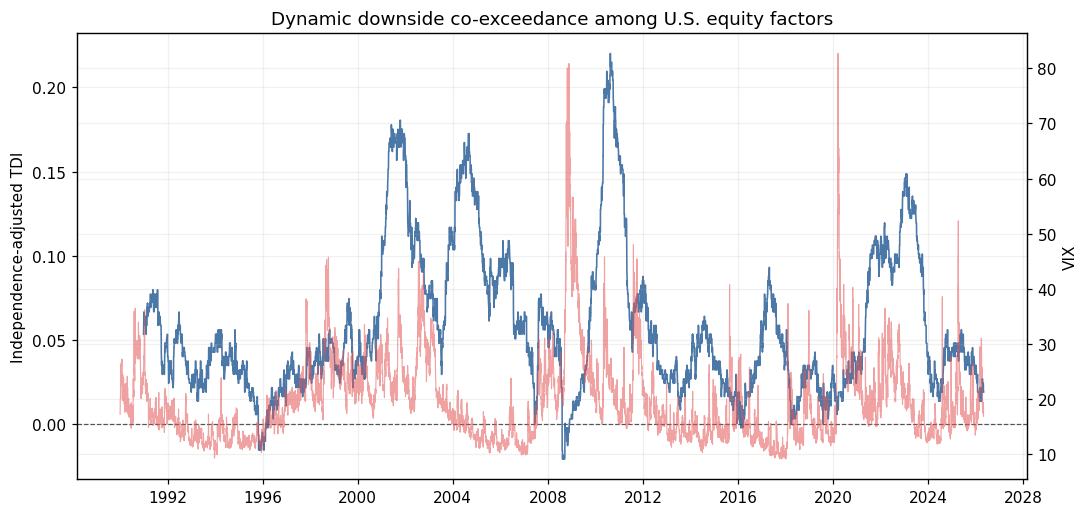

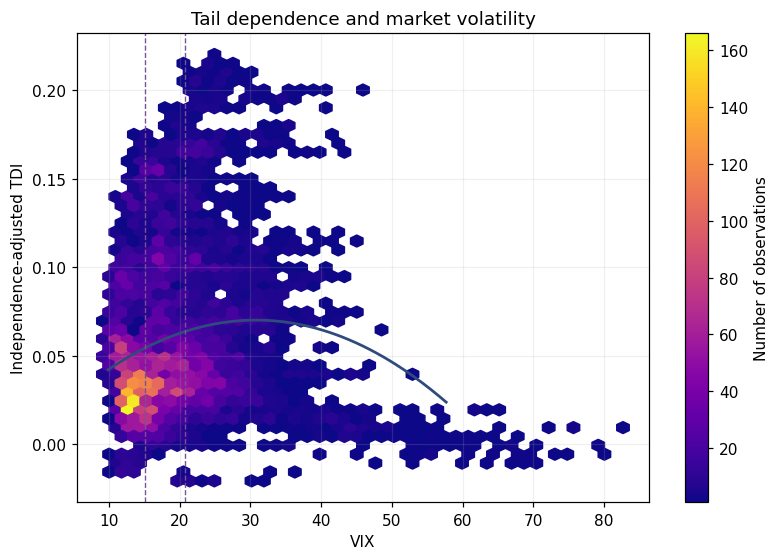

In [5]:
# Figure 1: dynamic TDI and VIX
vix_daily = vix.reindex(us_daily.index).ffill()
fig, ax1 = plt.subplots(figsize=(10, 4.8))
ax1.plot(tdi_daily.index, tdi_daily, lw=1.05, color="#4C78A8", label="Centered TDI")
ax1.axhline(0, lw=0.8, ls="--", color="#555555")
ax1.set_ylabel("Independence-adjusted TDI")
ax1.set_title("Dynamic downside co-exceedance among U.S. equity factors")
ax2 = ax1.twinx()
ax2.plot(vix_daily.index, vix_daily, lw=0.75, alpha=0.55, color="#E45756", label="VIX")
ax2.set_ylabel("VIX")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "Figure_1_Dynamic_TDI.png", dpi=220, bbox_inches="tight")
plt.show()

# Figure 2: TDI against VIX
plot_df = pd.concat([tdi_daily.rename("TDI"), vix_daily.rename("VIX")], axis=1).dropna()
fig, ax = plt.subplots(figsize=(7.4, 5.2))
hb = ax.hexbin(plot_df["VIX"], plot_df["TDI"], gridsize=42, mincnt=1, cmap="plasma")
coef = np.polyfit(plot_df["VIX"], plot_df["TDI"], 2)
grid = np.linspace(plot_df["VIX"].quantile(.005), plot_df["VIX"].quantile(.995), 200)
ax.plot(grid, np.polyval(coef, grid), lw=1.8, color="#2F4B7C")
for x in plot_df["VIX"].quantile([1/3, 2/3]):
    ax.axvline(x, lw=0.9, ls="--", color="#7A5195")
fig.colorbar(hb, ax=ax, label="Number of observations")
ax.set_xlabel("VIX")
ax.set_ylabel("Independence-adjusted TDI")
ax.set_title("Tail dependence and market volatility")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "Figure_2_TDI_VIX_Hexbin.png", dpi=220, bbox_inches="tight")
plt.show()


## 3. VIX regimes, pairwise copulas, rotations, and lower-versus-upper tail tests

,Regime,Avg. signed corr.,Avg. abs. corr.,Min pair corr.,Max pair corr.,N
0,Low,-0.046,0.181,-0.312,0.521,3052
1,Mid,-0.001,0.167,-0.355,0.554,3048
2,High,-0.019,0.222,-0.374,0.502,3049


,Pair,Low,Mid,High,High-Low,HAC p
0,MKT-SMB,0.229,0.171,0.108,-0.121,0.001
1,MKT-HML,0.029,0.105,0.134,0.105,0.253
2,MKT-RMW,0.075,0.075,0.069,-0.006,0.393
3,MKT-CMA,0.066,0.115,0.079,0.013,0.874
4,MKT-MOM,0.236,0.246,0.216,-0.019,0.283
5,SMB-HML,0.118,0.164,0.184,0.066,0.243
6,SMB-RMW,0.062,0.043,0.069,0.007,0.193
7,SMB-CMA,0.121,0.174,0.154,0.033,0.814
8,SMB-MOM,0.157,0.197,0.131,-0.026,0.087
9,HML-RMW,0.095,0.098,0.194,0.098,0.210


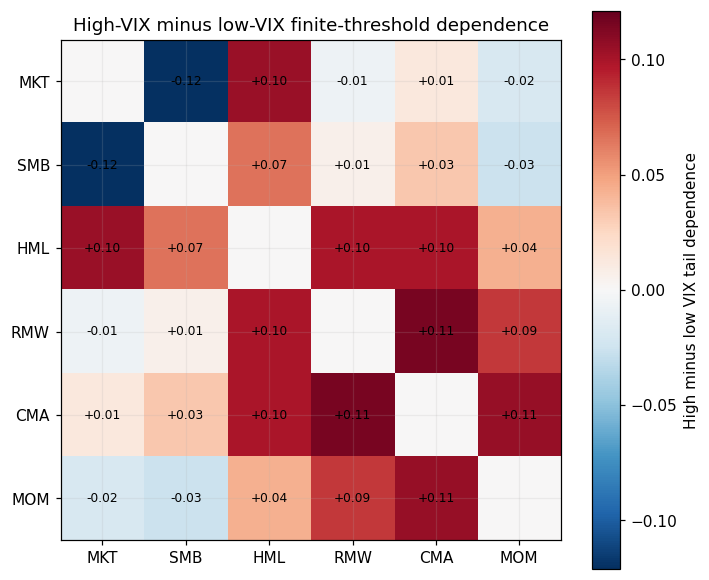

In [6]:
def hac_difference_p(series, regime, low="Low", high="High", lags=12):
    df = pd.DataFrame({"y": series, "regime": regime}).dropna()
    df["high"] = (df["regime"] == high).astype(float)
    df["mid"] = (df["regime"] == "Mid").astype(float)
    model = sm.OLS(df["y"], sm.add_constant(df[["mid", "high"]])).fit(cov_type="HAC", cov_kwds={"maxlags": lags})
    return float(model.pvalues["high"])

vix_cut = vix_daily.dropna().quantile([1/3, 2/3]).values
regime_daily = pd.cut(vix_daily, [-np.inf, vix_cut[0], vix_cut[1], np.inf], labels=["Low", "Mid", "High"])

panel_a = []
for regime in ["Low", "Mid", "High"]:
    x = us_daily.loc[regime_daily == regime]
    corr = x.corr().values
    vals = corr[np.triu_indices(len(FACTORS), 1)]
    panel_a.append({
        "Regime": regime,
        "Avg. signed corr.": vals.mean(),
        "Avg. abs. corr.": np.abs(vals).mean(),
        "Min pair corr.": vals.min(),
        "Max pair corr.": vals.max(),
        "N": len(x),
    })
panel_a = pd.DataFrame(panel_a)

pair_names = []
regime_tail = {r: {} for r in ["Low", "Mid", "High"]}
for i in range(6):
    for j in range(i + 1, 6):
        pair = f"{FACTORS[i]}-{FACTORS[j]}"
        pair_names.append(pair)
        for regime in ["Low", "Mid", "High"]:
            x = z_daily.loc[regime_daily == regime, [FACTORS[i], FACTORS[j]]].dropna()
            regime_tail[regime][pair] = pair_tail_matrix(x, TAIL_Q).iloc[0, 1]

panel_b = []
for pair in pair_names:
    low, mid, high = (regime_tail[r][pair] for r in ["Low", "Mid", "High"])
    # HAC test on monthly pairwise rolling tail-dependence series
    a, b = pair.split("-")
    pair_series = []
    for date in us_monthly.index:
        x = z_daily.loc[:date, [a, b]].tail(TDI_WINDOW)
        pair_series.append(pair_tail_matrix(x, TAIL_Q).iloc[0, 1] if len(x) == TDI_WINDOW else np.nan)
    pair_series = pd.Series(pair_series, index=us_monthly.index)
    vix_m = vix.resample("ME").last().reindex(us_monthly.index).ffill()
    cuts = vix_m.dropna().quantile([1/3, 2/3]).values
    reg_m = pd.cut(vix_m, [-np.inf, cuts[0], cuts[1], np.inf], labels=["Low", "Mid", "High"])
    panel_b.append({"Pair": pair, "Low": low, "Mid": mid, "High": high, "High-Low": high-low, "HAC p": hac_difference_p(pair_series, reg_m)})
panel_b = pd.DataFrame(panel_b)

panel_a.to_csv(TABLE_DIR / "Table_3A_VIX_Regime_Correlation.csv", index=False)
panel_b.to_csv(TABLE_DIR / "Table_3B_VIX_Regime_Tail_Dependence.csv", index=False)
display(panel_a.round(3))
display(panel_b.round(3))

matrix = pd.DataFrame(np.zeros((6,6)), index=FACTORS, columns=FACTORS)
for _, row in panel_b.iterrows():
    a,b = row["Pair"].split("-")
    matrix.loc[a,b] = matrix.loc[b,a] = row["High-Low"]
fig, ax = plt.subplots(figsize=(6.6,5.6))
im = ax.imshow(matrix.values, cmap="RdBu_r", vmin=-np.nanmax(np.abs(matrix.values)), vmax=np.nanmax(np.abs(matrix.values)))
ax.set_xticks(range(6), FACTORS)
ax.set_yticks(range(6), FACTORS)
for i in range(6):
    for j in range(6):
        if i != j:
            ax.text(j, i, f"{matrix.iloc[i,j]:+.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, label="High minus low VIX tail dependence")
ax.set_title("High-VIX minus low-VIX finite-threshold dependence")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "Figure_3_Regime_Tail_Heatmap.png", dpi=220, bbox_inches="tight")
plt.show()

In [7]:
def pseudo_obs(x):
    x = np.asarray(x, float)
    n = len(x)
    return np.column_stack([stats.rankdata(x[:, j], method="average") / (n + 1) for j in range(x.shape[1])])


def gaussian_copula_loglik(u, rho):
    z = stats.norm.ppf(np.clip(u, 1e-10, 1-1e-10))
    rho = float(np.clip(rho, -0.999, 0.999))
    den = 1 - rho*rho
    return float(np.sum(-0.5*np.log(den) - (rho*rho*(z[:,0]**2+z[:,1]**2)-2*rho*z[:,0]*z[:,1])/(2*den)))


def student_copula_loglik_bivariate(u, rho, nu):
    u = np.clip(u, 1e-10, 1-1e-10)
    rho = float(np.clip(rho, -0.995, 0.995))
    nu = float(max(nu, 2.05))
    x = stats.t.ppf(u, nu)
    R = np.array([[1, rho], [rho, 1.]])
    inv = np.linalg.inv(R)
    logdet = np.linalg.slogdet(R)[1]
    quad = np.einsum("ij,jk,ik->i", x, inv, x)
    log_joint = special.gammaln((nu+2)/2) - special.gammaln(nu/2) - 0.5*logdet - np.log(nu*np.pi) - (nu+2)/2*np.log1p(quad/nu)
    return float(np.sum(log_joint - np.sum(stats.t.logpdf(x, nu), axis=1)))


def fit_gaussian_pair(u):
    z = stats.norm.ppf(np.clip(u, 1e-8, 1-1e-8))
    rho = np.corrcoef(z.T)[0,1]
    ll = gaussian_copula_loglik(u, rho)
    return rho, ll, -2*ll + np.log(len(u))


def fit_student_pair(u):
    tau = stats.kendalltau(u[:,0], u[:,1]).statistic
    rho0 = np.sin(np.pi*tau/2)
    def objective(p):
        rho = np.tanh(p[0])
        nu = 2.01 + np.exp(p[1])
        return 1e9 if nu > 80 else -student_copula_loglik_bivariate(u, rho, nu)
    result = optimize.minimize(objective, [np.arctanh(np.clip(rho0,-.95,.95)), np.log(4)], method="Nelder-Mead", options={"maxiter":300})
    rho = np.tanh(result.x[0])
    nu = 2.01 + np.exp(result.x[1])
    ll = -result.fun
    bic = -2*ll + 2*np.log(len(u))
    lam = 2*stats.t.cdf(-np.sqrt((nu+1)*(1-rho)/(1+rho)), df=nu+1)
    return rho, nu, ll, bic, lam


def rotate_uv(u, rotation):
    if rotation == 0:
        return u.copy()
    if rotation == 90:
        return np.column_stack([1-u[:,0], u[:,1]])
    if rotation == 180:
        return 1-u
    return np.column_stack([u[:,0], 1-u[:,1]])


def clayton_log_density(u, theta):
    u = np.clip(u, 1e-10, 1-1e-10)
    a, b = u[:,0], u[:,1]
    s = a**(-theta) + b**(-theta) - 1
    return np.log1p(theta) + (-1-theta)*(np.log(a)+np.log(b)) + (-2-1/theta)*np.log(s)


def gumbel_log_density(u, theta):
    u = np.clip(u, 1e-10, 1-1e-10)
    a, b = -np.log(u[:,0]), -np.log(u[:,1])
    A = a**theta + b**theta
    C = np.exp(-(A**(1/theta)))
    density = C/(u[:,0]*u[:,1]) * (a*b)**(theta-1) * A**(2/theta-2) * (1+(theta-1)*A**(-1/theta))
    return np.log(np.maximum(density, 1e-300))


def best_rotated_archimedean(u, family):
    best = None
    for rotation in [0, 90, 180, 270]:
        ur = rotate_uv(u, rotation)
        if family == "Clayton":
            objective = lambda theta: -np.sum(clayton_log_density(ur, theta))
            bounds = (1e-4, 20)
        else:
            objective = lambda theta: -np.sum(gumbel_log_density(ur, theta))
            bounds = (1.0001, 20)
        result = optimize.minimize_scalar(objective, bounds=bounds, method="bounded")
        theta = result.x
        ll = -result.fun
        bic = -2*ll + np.log(len(u))
        tail = 2**(-1/theta) if family == "Clayton" else 2 - 2**(1/theta)
        lam_l = lam_u = 0.0
        if family == "Clayton" and rotation == 0: lam_l = tail
        if family == "Clayton" and rotation == 180: lam_u = tail
        if family == "Gumbel" and rotation == 0: lam_u = tail
        if family == "Gumbel" and rotation == 180: lam_l = tail
        row = {"rotation": rotation, "theta": theta, "ll": ll, "bic": bic, "lambdaL": lam_l, "lambdaU": lam_u}
        if best is None or row["bic"] < best["bic"]:
            best = row
    return best

In [8]:
copula_rows = []
for i in range(6):
    for j in range(i+1, 6):
        pair = f"{FACTORS[i]}-{FACTORS[j]}"
        u = pseudo_obs(z_daily[[FACTORS[i], FACTORS[j]]].dropna().values)
        g_rho, g_ll, g_bic = fit_gaussian_pair(u)
        t_rho, t_nu, t_ll, t_bic, t_lam = fit_student_pair(u)
        clayton = best_rotated_archimedean(u, "Clayton")
        gumbel = best_rotated_archimedean(u, "Gumbel")
        copula_rows.append({
            "Pair": pair,
            "Gaussian BIC": g_bic,
            "Student BIC": t_bic,
            "rho": t_rho,
            "nu": t_nu,
            "lambdaL=lambdaU": t_lam,
            "Best Clayton rotation": f"Clayton-{clayton['rotation']}",
            "Clayton BIC": clayton["bic"],
            "Best Gumbel rotation": f"Gumbel-{gumbel['rotation']}",
            "Gumbel BIC": gumbel["bic"],
            "Clayton lambdaL": clayton["lambdaL"],
            "Clayton lambdaU": clayton["lambdaU"],
            "Gumbel lambdaL": gumbel["lambdaL"],
            "Gumbel lambdaU": gumbel["lambdaU"],
        })

copula_pairs = pd.DataFrame(copula_rows)
copula_pairs.to_csv(TABLE_DIR / "Appendix_Table_A1_Pairwise_Copulas.csv", index=False)

family_summary = pd.DataFrame([
    ["Gaussian", 15, copula_pairs["Gaussian BIC"].mean(), 0, 0],
    ["Student-t", 15, copula_pairs["Student BIC"].mean(), copula_pairs["lambdaL=lambdaU"].mean(), copula_pairs["lambdaL=lambdaU"].mean()],
    ["Best rotated Clayton", 15, copula_pairs["Clayton BIC"].mean(), copula_pairs["Clayton lambdaL"].mean(), copula_pairs["Clayton lambdaU"].mean()],
    ["Best rotated Gumbel", 15, copula_pairs["Gumbel BIC"].mean(), copula_pairs["Gumbel lambdaL"].mean(), copula_pairs["Gumbel lambdaU"].mean()],
], columns=["Family specification", "Pairs", "Mean BIC", "Mean lambdaL", "Mean lambdaU"])
family_summary.to_csv(TABLE_DIR / "Table_4A_Copula_Family_Summary.csv", index=False)
display(family_summary.round(3))

,Family specification,Pairs,Mean BIC,Mean lambdaL,Mean lambdaU
0,Gaussian,15,-361.469,0.000,0.000
1,Student-t,15,-664.065,0.055,0.055
2,Best rotated Clayton,15,-360.637,0.000,0.028
3,Best rotated Gumbel,15,-451.985,0.015,0.038


,Pair,q,Lower,Upper,Lower-Upper,CI low,CI high,p,FDR q within threshold,FDR q all 30
26,HML-MOM,0.1,0.136,0.089,0.047,0.021,0.075,0.000,0.000,0.000
29,CMA-MOM,0.1,0.160,0.117,0.043,0.013,0.072,0.000,0.000,0.000
24,HML-RMW,0.1,0.130,0.185,-0.055,-0.087,-0.022,0.004,0.020,0.030
22,SMB-CMA,0.1,0.160,0.120,0.039,0.012,0.068,0.012,0.045,0.060
27,RMW-CMA,0.1,0.144,0.185,-0.040,-0.075,-0.008,0.016,0.048,0.069


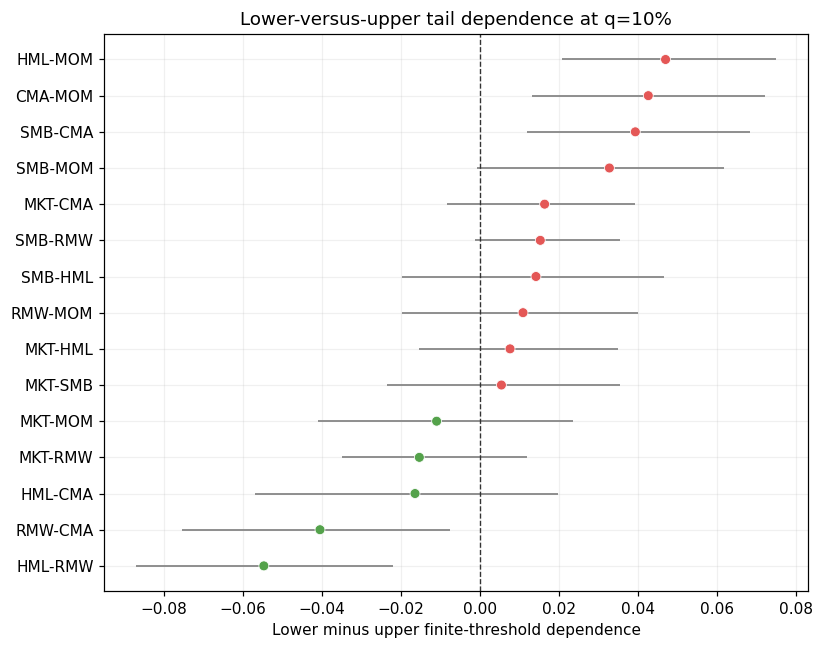

In [9]:
def circular_block_indices(n, block_length, rng):
    blocks = int(np.ceil(n / block_length))
    starts = rng.integers(0, n, blocks)
    return np.concatenate([(s + np.arange(block_length)) % n for s in starts])[:n]


def lower_upper_tail(x, q):
    u = pseudo_obs(np.asarray(x, float))
    lower = np.mean((u[:, 0] <= q) & (u[:, 1] <= q)) / q
    upper = np.mean((u[:, 0] >= 1-q) & (u[:, 1] >= 1-q)) / q
    return lower, upper, lower-upper


def tail_asymmetry_table(z, q, B=499, block_length=20, seed=123):
    rng = np.random.default_rng(seed)
    rows = []
    for i in range(6):
        for j in range(i+1, 6):
            x = z.iloc[:, [i, j]].dropna().values
            lower, upper, diff = lower_upper_tail(x, q)
            boot = np.empty(B)
            for b in range(B):
                idx = circular_block_indices(len(x), block_length, rng)
                boot[b] = lower_upper_tail(x[idx], q)[2]
            lo, hi = np.quantile(boot, [.025, .975])
            p = min(1.0, 2 * min(np.mean(boot <= 0), np.mean(boot >= 0)))
            rows.append([f"{FACTORS[i]}-{FACTORS[j]}", q, lower, upper, diff, lo, hi, p])
    return pd.DataFrame(rows, columns=["Pair", "q", "Lower", "Upper", "Lower-Upper", "CI low", "CI high", "p"])


asym_05 = tail_asymmetry_table(z_daily, .05, SIGNAL_BOOTSTRAPS, 20, RANDOM_SEED+1)
asym_10 = tail_asymmetry_table(z_daily, .10, SIGNAL_BOOTSTRAPS, 20, RANDOM_SEED+2)
asymmetry = pd.concat([asym_05, asym_10], ignore_index=True)

# Multiple-testing correction: 15 pairs at each q, and all 30 tests jointly.
asymmetry["FDR q within threshold"] = np.nan
for q_value in sorted(asymmetry["q"].unique()):
    mask = asymmetry["q"] == q_value
    asymmetry.loc[mask, "FDR q within threshold"] = multipletests(
        asymmetry.loc[mask, "p"].values, method="fdr_bh"
    )[1]
asymmetry["FDR q all 30"] = multipletests(asymmetry["p"].values, method="fdr_bh")[1]
asymmetry.to_csv(TABLE_DIR / "Appendix_Table_A2_Lower_Upper_Asymmetry.csv", index=False)

table4b = asymmetry[(asymmetry["q"] == .10) & (asymmetry["FDR q within threshold"] < .10)].sort_values("FDR q within threshold")
table4b.to_csv(TABLE_DIR / "Table_4B_FDR_Adjusted_Tail_Asymmetry.csv", index=False)
display(table4b.round(3))

plot = asym_10.sort_values("Lower-Upper").copy()
fig, ax = plt.subplots(figsize=(7.6, 6.0))
y = np.arange(len(plot))
ax.hlines(y, plot["CI low"].values, plot["CI high"].values, lw=1.25, color="#8C8C8C")
point_colors = ["#E45756" if x > 0 else "#54A24B" for x in plot["Lower-Upper"]]
ax.scatter(plot["Lower-Upper"].values, y, s=42, c=point_colors, edgecolor="white", linewidth=.5, zorder=3)
ax.axvline(0, lw=0.9, ls="--", color="#333333")
ax.set_yticks(y, plot["Pair"])
ax.set_xlabel("Lower minus upper finite-threshold dependence")
ax.set_title("Lower-versus-upper tail dependence at q=10%")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "Figure_4_Lower_Upper_Tail.png", dpi=220, bbox_inches="tight")
plt.show()


## 4. Recursive crash prediction and generated-regressor inference

In [10]:
eq_return = us_monthly.mean(axis=1)
realized_vol = eq_return.rolling(12).std() * np.sqrt(12)

avg_abs_corr = []
for t in range(len(us_monthly)):
    if t < 59:
        avg_abs_corr.append(np.nan)
    else:
        corr = us_monthly.iloc[t-59:t+1].corr().values
        avg_abs_corr.append(np.mean(np.abs(corr[np.triu_indices(6,1)])))
avg_abs_corr = pd.Series(avg_abs_corr, index=us_monthly.index)

vix_monthly = vix.resample("ME").last().reindex(us_monthly.index).ffill()
term_monthly = (dgs10-dtb3).resample("ME").last().reindex(us_monthly.index).ffill()
credit_monthly = credit.resample("ME").last().reindex(us_monthly.index).ffill()
nfci_monthly = nfci.resample("ME").last().reindex(us_monthly.index).ffill()

states = pd.DataFrame({
    "TDI": tdi_monthly.reindex(us_monthly.index),
    "VIX": vix_monthly,
    "Realized volatility": realized_vol,
    "Avg. abs. correlation": avg_abs_corr,
    "Term spread": term_monthly,
    "Credit spread": credit_monthly,
    "NFCI": nfci_monthly,
})

state_z = pd.DataFrame(index=states.index)
for c in states.columns:
    expanding_mean = states[c].expanding(12).mean()
    expanding_std = states[c].expanding(12).std(ddof=1)
    state_z[c] = (states[c] - expanding_mean) / expanding_std

crash_cutoff = eq_return.expanding(60).quantile(.10)
future_eq_return = eq_return.shift(-1)
crash_next = (future_eq_return <= crash_cutoff).astype(float)
crash_next[future_eq_return.isna()] = np.nan

predictive = pd.DataFrame(index=us_monthly.index)
predictive["Crash_next"] = crash_next
predictive["Return_next"] = future_eq_return
predictive = predictive.join(state_z).dropna()

print("Predictive sample:", len(predictive), predictive.index.min().date(), "to", predictive.index.max().date())

Predictive sample: 365 1995-11-30 to 2026-03-31


In [11]:
def ols_hac(y, X, lags=HAC_LAGS):
    return sm.OLS(y, sm.add_constant(X, has_constant="add")).fit(
        cov_type="HAC", cov_kwds={"maxlags": lags}
    )


def binary_hac(y, X, kind="logit", lags=HAC_LAGS):
    X = sm.add_constant(X, has_constant="add")
    model = sm.Logit(y, X) if kind == "logit" else sm.Probit(y, X)
    return model.fit(disp=0, cov_type="HAC", cov_kwds={"maxlags": lags})


specs = {
    "Tail LPM": ["TDI"],
    "Market LPM": ["TDI", "VIX", "Realized volatility", "Avg. abs. correlation"],
    "Full LPM": ["TDI", "VIX", "Realized volatility", "Avg. abs. correlation", "Term spread", "Credit spread", "NFCI"],
}

models = {name: ols_hac(predictive["Crash_next"], predictive[cols]) for name, cols in specs.items()}
models["Logit"] = binary_hac(predictive["Crash_next"], predictive[specs["Full LPM"]], "logit")
models["Probit"] = binary_hac(predictive["Crash_next"], predictive[specs["Full LPM"]], "probit")
models["Return OLS"] = ols_hac(predictive["Return_next"], predictive[specs["Full LPM"]])

variables = ["TDI", "VIX", "Realized volatility", "Avg. abs. correlation", "Term spread", "Credit spread", "NFCI"]
reg_table = []
for var in variables:
    row = {"Variable": var}
    for name, model in models.items():
        if var in model.params.index:
            row[name] = model.params[var]
            row[name + " t"] = model.tvalues[var]
            row[name + " p"] = model.pvalues[var]
    reg_table.append(row)
reg_table = pd.DataFrame(reg_table)
reg_table.to_csv(TABLE_DIR / "Table_5A_Predictive_Regressions.csv", index=False)
display(reg_table.round(4))


,Variable,Tail LPM,Tail LPM t,Tail LPM p,Market LPM,Market LPM t,Market LPM p,Full LPM,Full LPM t,Full LPM p,Logit,Logit t,Logit p,Probit,Probit t,Probit p,Return OLS,Return OLS t,Return OLS p
0,TDI,0.0225,1.4284,0.1532,0.0212,0.9747,0.3297,0.0429,1.7919,0.0731,0.3433,1.7413,0.0816,0.1720,1.6889,0.0912,-0.0014,-1.3618,0.1732
1,VIX,NaN,NaN,NaN,0.0689,3.9223,0.0001,0.0520,2.3557,0.0185,0.3713,2.7213,0.0065,0.2052,2.4487,0.0143,-0.0007,-0.6821,0.4952
2,Realized volatility,NaN,NaN,NaN,-0.0038,-0.1737,0.8621,-0.0262,-1.1178,0.2636,-0.1948,-0.9828,0.3257,-0.0931,-0.8793,0.3792,0.0030,2.2409,0.0250
3,Avg. abs. correlation,NaN,NaN,NaN,-0.0031,-0.1523,0.8790,-0.0124,-0.5666,0.5710,-0.0836,-0.5258,0.5990,-0.0313,-0.3499,0.7264,0.0023,2.3180,0.0204
4,Term spread,NaN,NaN,NaN,NaN,NaN,NaN,-0.0358,-1.4150,0.1571,-0.2771,-1.2119,0.2255,-0.1326,-1.1239,0.2611,0.0025,2.4350,0.0149
5,Credit spread,NaN,NaN,NaN,NaN,NaN,NaN,0.0330,1.1127,0.2658,0.2066,0.8429,0.3993,0.0885,0.6680,0.5041,-0.0027,-2.3745,0.0176
6,NFCI,NaN,NaN,NaN,NaN,NaN,NaN,0.0114,0.4419,0.6585,0.0725,0.3883,0.6978,0.0594,0.5704,0.5684,0.0001,0.1311,0.8957


In [12]:
CRASH_SPECS = [
    ("Rolling W126 q05", 126, .05, "rolling"),
    ("Rolling W126 q10", 126, .10, "rolling"),
    ("Rolling W252 q05", 252, .05, "rolling"),
    ("Baseline W252 q10", 252, .10, "rolling"),
    ("Rolling W504 q05", 504, .05, "rolling"),
    ("Rolling W504 q10", 504, .10, "rolling"),
    ("Expanding W252 q10", 252, .10, "expanding"),
    ("Fixed W252 q10", 252, .10, "fixed"),
]


def predictive_data_for_tdi(tdi_series):
    """Rebuild the standardized state vector for one TDI specification."""
    state = states.copy()
    state["TDI"] = tdi_series.reindex(state.index)
    z_state = pd.DataFrame(index=state.index)
    for column in state:
        mean = state[column].expanding(12).mean()
        std = state[column].expanding(12).std(ddof=1)
        z_state[column] = (state[column] - mean) / std
    z_state["y"] = crash_next
    return z_state.dropna()


def fit_full_lpm_for_tdi(tdi_series, lags=12):
    dat = predictive_data_for_tdi(tdi_series)
    fit = ols_hac(dat["y"], dat[specs["Full LPM"]], lags)
    return fit, dat


def tdi_at_indices(z_values, target_indices, window=252, q=.10, mode="rolling"):
    """Compute the original finite-threshold TDI only at requested daily positions.

    This reproduces the manuscript definition but avoids recomputing thousands of
    unnecessary daily values inside each bootstrap replication.
    """
    arr = np.asarray(z_values, float)
    k = arr.shape[1]
    pairs = [(i, j) for i in range(k) for j in range(i+1, k)]
    fixed_threshold = np.nanquantile(arr[:min(1260, len(arr))], q, axis=0)
    values = np.full(len(target_indices), np.nan)

    for n, pos in enumerate(target_indices):
        if pos < window-1:
            continue
        block = arr[pos-window+1:pos+1]
        if mode == "rolling":
            threshold = np.nanquantile(block, q, axis=0)
        elif mode == "expanding":
            threshold = np.nanquantile(arr[:pos+1], q, axis=0)
        elif mode == "fixed":
            threshold = fixed_threshold
        else:
            raise ValueError("mode must be rolling, expanding, or fixed")
        indicator = (block <= threshold).astype(float)
        joint = indicator.T @ indicator / window / q
        values[n] = np.mean([joint[i, j] for i, j in pairs]) - q
    return values


def tdi_specs_from_daily_z(z):
    daily_positions = np.searchsorted(z.index.values, us_monthly.index.values, side="right") - 1
    out = {}
    for label, window, q, mode in CRASH_SPECS:
        values = tdi_at_indices(z.values, daily_positions, window, q, mode)
        out[label] = pd.Series(values, index=us_monthly.index, name="TDI")
    return out


# Original-sample estimates for every window/threshold specification.
tdi_spec_series = tdi_specs_from_daily_z(z_daily)
crash_rows = []
for label, window, q, mode in CRASH_SPECS:
    tdi_m = tdi_spec_series[label]
    fit12, dat = fit_full_lpm_for_tdi(tdi_m, 12)
    fit6, _ = fit_full_lpm_for_tdi(tdi_m, 6)
    fit18, _ = fit_full_lpm_for_tdi(tdi_m, 18)
    beta = float(fit12.params["TDI"])
    se = float(fit12.bse["TDI"])
    mde80 = (stats.norm.ppf(.975) + stats.norm.ppf(.80)) * se
    crash_rows.append({
        "Specification": label,
        "Threshold mode": mode,
        "Window": window,
        "q": q,
        "N": len(dat),
        "Crash events": int(dat["y"].sum()),
        "TDI beta": beta,
        "HAC SE (12)": se,
        "HAC p (6)": float(fit6.pvalues["TDI"]),
        "HAC p (12)": float(fit12.pvalues["TDI"]),
        "HAC p (18)": float(fit18.pvalues["TDI"]),
        "80% MDE": mde80,
    })
crash_spec_table = pd.DataFrame(crash_rows)


def generated_signal_bootstrap_grid(B=499, block_months=12, seed=12345):
    """Block bootstrap that reconstructs EWMA residuals, every TDI specification,
    the recursive crash cutoff and macro controls in each replication.

    All eight specifications are evaluated on the same resampled path in each draw,
    so cross-specification comparisons are not driven by different bootstrap samples.
    """
    rng = np.random.default_rng(seed)
    months = pd.period_range(us_monthly.index.min(), us_monthly.index.max(), freq="M")
    daily_month = us_daily.index.to_period("M")
    daily_groups = {m: us_daily.loc[daily_month == m].values for m in months}

    raw_controls = pd.DataFrame({
        "VIX": vix_monthly,
        "Term spread": term_monthly,
        "Credit spread": credit_monthly,
        "NFCI": nfci_monthly,
    }).reindex(us_monthly.index)

    draws = {label: [] for label, _, _, _ in CRASH_SPECS}
    n_months = len(months)

    for _ in range(B):
        idx = circular_block_indices(n_months, block_months, rng)
        chosen = months[idx]
        daily_blocks = [daily_groups[m] for m in chosen]
        month_lengths = [len(x) for x in daily_blocks]
        daily_array = np.vstack(daily_blocks)

        # Filter once, then build every TDI definition from the same bootstrap path.
        z_b, _, _ = ewma_filter(pd.DataFrame(daily_array), EWMA_DECAY)
        month_ends = np.cumsum(month_lengths) - 1

        ret_b = us_monthly.iloc[idx].reset_index(drop=True)
        eq_b = ret_b.mean(axis=1)
        rv_b = eq_b.rolling(12).std() * np.sqrt(12)
        corr_b = []
        for t in range(n_months):
            if t < 59:
                corr_b.append(np.nan)
            else:
                C = ret_b.iloc[t-59:t+1].corr().values
                corr_b.append(np.mean(np.abs(C[np.triu_indices(6, 1)])))

        controls_b = raw_controls.iloc[idx].reset_index(drop=True)
        cutoff_b = eq_b.expanding(60).quantile(.10)
        future_b = eq_b.shift(-1)
        y_b = (future_b <= cutoff_b).astype(float)
        y_b[future_b.isna()] = np.nan

        for label, window, q, mode in CRASH_SPECS:
            tdi_values = tdi_at_indices(z_b.values, month_ends, window, q, mode)
            tdi_b = pd.Series(tdi_values, index=range(n_months))

            state_b = pd.DataFrame({
                "TDI": tdi_b,
                "VIX": controls_b["VIX"],
                "Realized volatility": rv_b,
                "Avg. abs. correlation": corr_b,
                "Term spread": controls_b["Term spread"],
                "Credit spread": controls_b["Credit spread"],
                "NFCI": controls_b["NFCI"],
            })
            z_state = pd.DataFrame(index=state_b.index)
            for column in state_b:
                mean = state_b[column].expanding(12).mean()
                std = state_b[column].expanding(12).std(ddof=1)
                z_state[column] = (state_b[column] - mean) / std
            z_state["y"] = y_b
            dat = z_state.dropna()

            if len(dat) > 100 and dat["y"].nunique() > 1:
                fit = sm.OLS(
                    dat["y"], sm.add_constant(dat[specs["Full LPM"]], has_constant="add")
                ).fit()
                draws[label].append(float(fit.params["TDI"]))

    return {label: np.asarray(values) for label, values in draws.items()}


signal_boot_grid = generated_signal_bootstrap_grid(
    SIGNAL_BOOTSTRAPS, block_months=12, seed=RANDOM_SEED + 10
)

for i, row in crash_spec_table.iterrows():
    boot = signal_boot_grid[row["Specification"]]
    crash_spec_table.loc[i, "Bootstrap mean"] = np.mean(boot)
    crash_spec_table.loc[i, "Bootstrap CI low"] = np.quantile(boot, .025)
    crash_spec_table.loc[i, "Bootstrap CI high"] = np.quantile(boot, .975)
    crash_spec_table.loc[i, "Bootstrap p"] = min(
        1.0, 2 * min(np.mean(boot <= 0), np.mean(boot >= 0))
    )
    crash_spec_table.loc[i, "Bootstrap reps"] = len(boot)

# FDR correction across the six rolling (W,q) specifications highlighted by the reviewer concern.
rolling_mask = crash_spec_table["Threshold mode"].eq("rolling")
crash_spec_table["HAC FDR q (six rolling)"] = np.nan
crash_spec_table["Bootstrap FDR q (six rolling)"] = np.nan
crash_spec_table.loc[rolling_mask, "HAC FDR q (six rolling)"] = multipletests(
    crash_spec_table.loc[rolling_mask, "HAC p (12)"].values, method="fdr_bh"
)[1]
crash_spec_table.loc[rolling_mask, "Bootstrap FDR q (six rolling)"] = multipletests(
    crash_spec_table.loc[rolling_mask, "Bootstrap p"].values, method="fdr_bh"
)[1]

# A second adjustment reports the family of all eight threshold/window variants.
crash_spec_table["HAC FDR q (all eight)"] = multipletests(
    crash_spec_table["HAC p (12)"].values, method="fdr_bh"
)[1]
crash_spec_table["Bootstrap FDR q (all eight)"] = multipletests(
    crash_spec_table["Bootstrap p"].values, method="fdr_bh"
)[1]

crash_spec_table.to_csv(TABLE_DIR / "Table_5B_Crash_Specification_Bootstrap.csv", index=False)
display(crash_spec_table.round(4))

baseline = crash_spec_table.loc[crash_spec_table["Specification"] == "Baseline W252 q10"].iloc[0]
table5c = pd.DataFrame({
    "Baseline inference item": [
        "TDI coefficient", "HAC SE (12 lags)", "HAC p-value", "Signal-reconstruction bootstrap p-value",
        "80% minimum detectable effect", "Crash events", "Predictive observations",
    ],
    "Value": [
        baseline["TDI beta"], baseline["HAC SE (12)"], baseline["HAC p (12)"], baseline["Bootstrap p"],
        baseline["80% MDE"], baseline["Crash events"], baseline["N"],
    ],
})
table5c.to_csv(TABLE_DIR / "Table_5C_Baseline_Crash_Power.csv", index=False)
display(table5c.round(4))


,Specification,Threshold mode,Window,q,N,Crash events,TDI beta,HAC SE (12),HAC p (6),HAC p (12),HAC p (18),80% MDE,Bootstrap mean,Bootstrap CI low,Bootstrap CI high,Bootstrap p,Bootstrap reps,HAC FDR q (six rolling),Bootstrap FDR q (six rolling),HAC FDR q (all eight),Bootstrap FDR q (all eight)
0,Rolling W126 q05,rolling,126,0.05,365,52,0.0519,0.0210,0.0167,0.0133,0.0057,0.0588,0.0315,-0.0067,0.0744,0.1042,499.0,0.0266,0.3126,0.0355,0.3046
1,Rolling W126 q10,rolling,126,0.10,365,52,0.0613,0.0201,0.0031,0.0023,0.0011,0.0563,0.0353,-0.0055,0.0791,0.0922,499.0,0.0137,0.3126,0.0182,0.3046
2,Rolling W252 q05,rolling,252,0.05,365,52,0.0593,0.0225,0.0155,0.0084,0.0028,0.0631,0.0232,-0.0108,0.0676,0.2485,499.0,0.0253,0.3727,0.0337,0.3313
3,Baseline W252 q10,rolling,252,0.10,365,52,0.0429,0.0239,0.1037,0.0731,0.0535,0.0671,0.0250,-0.0108,0.0676,0.2285,499.0,0.0731,0.3727,0.0975,0.3313
4,Rolling W504 q05,rolling,504,0.05,365,52,0.0414,0.0199,0.0560,0.0375,0.0274,0.0557,0.0141,-0.0166,0.0462,0.4289,499.0,0.0537,0.4289,0.0717,0.4289
5,Rolling W504 q10,rolling,504,0.10,365,52,0.0403,0.0201,0.0672,0.0448,0.0477,0.0563,0.0146,-0.0158,0.0473,0.3808,499.0,0.0537,0.4289,0.0717,0.4289
6,Expanding W252 q10,expanding,252,0.10,365,52,0.0252,0.0193,0.2311,0.1915,0.1518,0.0540,0.0250,-0.0068,0.0621,0.1523,499.0,NaN,NaN,0.2188,0.3046
7,Fixed W252 q10,fixed,252,0.10,365,52,0.0219,0.0183,0.2677,0.2329,0.1936,0.0514,0.0257,-0.0086,0.0667,0.1523,499.0,NaN,NaN,0.2329,0.3046


,Baseline inference item,Value
0,TDI coefficient,0.0429
1,HAC SE (12 lags),0.0239
2,HAC p-value,0.0731
3,Signal-reconstruction bootstrap p-value,0.2285
4,80% minimum detectable effect,0.0671
5,Crash events,52.0000
6,Predictive observations,365.0000


## 5. Fully recursive VaR/ES forecasting

In [13]:
def nearest_correlation_higham(A, tol=1e-9, max_iter=100, eig_floor=1e-10):
    """Higham (2002) alternating projection onto PSD and unit-diagonal matrices."""
    A = np.asarray(A, float)
    Y = (A + A.T) / 2
    np.fill_diagonal(Y, 1.0)
    delta_s = np.zeros_like(Y)
    previous = Y.copy()

    for _ in range(max_iter):
        R = Y - delta_s
        eigval, eigvec = np.linalg.eigh((R + R.T) / 2)
        X = (eigvec * np.maximum(eigval, 0.0)) @ eigvec.T
        delta_s = X - R
        Y = X.copy()
        np.fill_diagonal(Y, 1.0)
        if np.linalg.norm(Y - previous, ord="fro") < tol:
            break
        previous = Y.copy()

    Y = (Y + Y.T) / 2
    min_eig = np.linalg.eigvalsh(Y).min()
    if min_eig < eig_floor:
        Y = Y + np.eye(len(Y)) * (eig_floor - min_eig)
        d = np.sqrt(np.diag(Y))
        Y = Y / np.outer(d, d)
    return (Y + Y.T) / 2


def return_var_es(x, alpha=.05):
    x = np.asarray(x, float)
    var = np.quantile(x, alpha)
    return float(var), float(x[x <= var].mean())


def normal_var_es(mu, sigma, alpha=.05):
    z = stats.norm.ppf(alpha)
    return mu + sigma*z, mu - sigma*stats.norm.pdf(z)/alpha


def standardized_t_var_es(mu, sigma, nu, alpha=.05):
    scale = np.sqrt((nu-2)/nu)
    q = stats.t.ppf(alpha, nu)
    var = mu + sigma * scale * q
    es_std = -stats.t.pdf(q, nu) * (nu+q*q) / ((nu-1)*alpha)
    return var, mu + sigma * scale * es_std


def multivariate_t_copula_loglik(U, R, nu):
    U = np.clip(U, 1e-10, 1-1e-10)
    X = stats.t.ppf(U, nu)
    log_joint = stats.multivariate_t.logpdf(X, loc=np.zeros(X.shape[1]), shape=R, df=nu)
    log_marginal = np.sum(stats.t.logpdf(X, nu), axis=1)
    return float(np.sum(log_joint - log_marginal))


def kendall_corr(U):
    k = U.shape[1]
    R = np.eye(k)
    for i in range(k):
        for j in range(i+1, k):
            tau = stats.kendalltau(U[:, i], U[:, j]).statistic
            R[i, j] = R[j, i] = np.sin(np.pi*tau/2)
    return nearest_correlation_higham(R)


def map_empirical_margins(window, U):
    sorted_window = np.sort(np.asarray(window), axis=0)
    n = len(sorted_window)
    idx = np.minimum((np.clip(U, 0, 1-1e-12) * n).astype(int), n-1)
    out = np.empty_like(U)
    for j in range(window.shape[1]):
        out[:, j] = sorted_window[idx[:, j], j]
    return out


def t_copula_scenarios_from_R(window, R, nu, n_sim=2048, seed=0):
    power = int(np.log2(n_sim))
    sobol = qmc.Sobol(d=window.shape[1]+1, scramble=True, seed=seed).random_base2(power)
    Z = stats.norm.ppf(np.clip(sobol[:, :-1], 1e-10, 1-1e-10)) @ np.linalg.cholesky(R).T
    chi = stats.chi2.ppf(np.clip(sobol[:, -1], 1e-10, 1-1e-10), nu)
    T = Z / np.sqrt(chi[:, None]/nu)
    U_sim = stats.t.cdf(T, nu)
    return map_empirical_margins(window, U_sim)


def copula_scenarios(window, kind="student", n_sim=2048, seed=0):
    U = pseudo_obs(window)
    R = kendall_corr(U)
    power = int(np.log2(n_sim))

    if kind == "gaussian":
        sobol = qmc.Sobol(d=window.shape[1], scramble=True, seed=seed).random_base2(power)
        Z = stats.norm.ppf(np.clip(sobol, 1e-10, 1-1e-10)) @ np.linalg.cholesky(R).T
        U_sim = stats.norm.cdf(Z)
        nu = np.nan
    else:
        ll = [multivariate_t_copula_loglik(U, R, nu) for nu in NU_GRID]
        nu = float(NU_GRID[int(np.argmax(ll))])
        return t_copula_scenarios_from_R(window, R, nu, n_sim, seed), R, nu

    return map_empirical_margins(window, U_sim), R, nu


In [14]:
def ewma_series_states(series, decay=.94):
    x = np.asarray(series, float)
    mu = np.empty(len(x)+1)
    var = np.empty(len(x)+1)
    mu[0] = np.mean(x[:20])
    var[0] = np.var(x[:20], ddof=1)
    for t in range(len(x)):
        err = x[t] - mu[t]
        mu[t+1] = decay*mu[t] + (1-decay)*x[t]
        var[t+1] = decay*var[t] + (1-decay)*err*err
    return mu, var


def ewma_matrix_states(df, decay=.94):
    x = np.asarray(df, float)
    n, k = x.shape
    mu = np.empty((n+1, k))
    var = np.empty((n+1, k))
    z = np.empty((n, k))
    mu[0] = x[:20].mean(0)
    var[0] = x[:20].var(0, ddof=1)
    for t in range(n):
        z[t] = (x[t]-mu[t]) / np.sqrt(np.maximum(var[t], 1e-12))
        err = x[t]-mu[t]
        mu[t+1] = decay*mu[t] + (1-decay)*x[t]
        var[t+1] = decay*var[t] + (1-decay)*err*err
    return mu, var, z


def garch_t_loglik(x, alpha, beta, nu):
    x = np.asarray(x, float)
    mu = x.mean()
    variance = max(x.var(ddof=1), 1e-8)
    omega = max((1-alpha-beta)*variance, 1e-10)
    h = variance
    scale = np.sqrt((nu-2)/nu)
    ll = 0.0
    for r in x:
        eps = (r-mu)/np.sqrt(max(h, 1e-12))
        ll += stats.t.logpdf(eps/scale, nu) - np.log(scale) - .5*np.log(max(h, 1e-12))
        h = omega + alpha*(r-mu)**2 + beta*h
    return ll


def fit_garch_t_grid(x):
    best = None
    for alpha in GARCH_ALPHA_GRID:
        for beta in GARCH_BETA_GRID:
            if alpha + beta >= .995:
                continue
            for nu in DCC_NU_GRID + [30]:
                ll = garch_t_loglik(x, alpha, beta, nu)
                if best is None or ll > best[0]:
                    best = (ll, alpha, beta, float(nu))
    return best[1:]


def garch_t_forecast(x, alpha, beta, nu):
    x = np.asarray(x, float)
    mu = x.mean()
    variance = max(x.var(ddof=1), 1e-8)
    omega = max((1-alpha-beta)*variance, 1e-10)
    h = variance
    for r in x:
        h = omega + alpha*(r-mu)**2 + beta*h
    return standardized_t_var_es(mu, np.sqrt(h), nu, ALPHA)


def dcc_path(z, a, b):
    z = np.asarray(z, float)
    S = nearest_correlation_higham(np.corrcoef(z.T))
    Q = S.copy()
    path = []
    for row in z:
        outer = np.outer(row, row)
        Q = (1-a-b)*S + a*outer + b*Q
        d = np.sqrt(np.maximum(np.diag(Q), 1e-12))
        path.append(nearest_correlation_higham(Q/np.outer(d, d)))
    return path, S, Q


def dcc_qml(z, a, b):
    path, _, _ = dcc_path(z, a, b)
    total = 0.0
    for row, R in zip(z, path):
        sign, logdet = np.linalg.slogdet(R)
        if sign <= 0:
            return -np.inf
        total += -.5*(logdet + row @ np.linalg.solve(R, row))
    return total


def fit_dcc_grid(z):
    best = None
    for a in DCC_A_GRID:
        for b in DCC_B_GRID:
            if a + b >= .995:
                continue
            ll = dcc_qml(z, a, b)
            if best is None or ll > best[0]:
                best = (ll, a, b)
    # A transparent heavy-tail grid based on the standardized equal-weight residual.
    ew = z.mean(axis=1)
    ew = (ew-ew.mean()) / max(ew.std(ddof=1), 1e-12)
    nu_ll = []
    for nu in DCC_NU_GRID:
        scale = np.sqrt((nu-2)/nu)
        nu_ll.append(np.sum(stats.t.logpdf(ew/scale, nu)-np.log(scale)))
    nu = float(DCC_NU_GRID[int(np.argmax(nu_ll))])
    return best[1], best[2], nu


def dcc_forecast_state(window, params):
    mu, var, z = ewma_matrix_states(window, EWMA_DECAY)
    a, b, nu = params
    path, S, Q = dcc_path(z, a, b)
    last = z[-1]
    Q_next = (1-a-b)*S + a*np.outer(last, last) + b*Q
    d = np.sqrt(np.maximum(np.diag(Q_next), 1e-12))
    R_next = nearest_correlation_higham(Q_next/np.outer(d, d))
    D = np.diag(np.sqrt(np.maximum(var[-1], 1e-12)))
    covariance = D @ R_next @ D
    return mu[-1], covariance, R_next, nu


def evt_pot_var_es(returns, alpha=.05, threshold_q=.80):
    loss = -np.asarray(returns, float)
    u = np.quantile(loss, threshold_q)
    exc = loss[loss > u] - u
    if len(exc) < 15:
        v, e = return_var_es(returns, alpha)
        return v, e
    try:
        xi, _, beta = stats.genpareto.fit(exc, floc=0)
        p_u = len(exc)/len(loss)
        if abs(xi) < 1e-6:
            var_loss = u + beta*np.log(p_u/alpha)
        else:
            var_loss = u + beta/xi*((alpha/p_u)**(-xi)-1)
        if xi >= .95:
            raise ValueError("unstable GPD mean")
        es_loss = (var_loss + beta - xi*u)/(1-xi)
        return -float(var_loss), -float(es_loss)
    except Exception:
        return return_var_es(returns, alpha)


def forecast_panel(monthly, n_sim=2048):
    monthly = monthly.dropna().copy()
    eq = monthly.mean(axis=1)
    rows, cache = [], {}
    garch_params = None
    dcc_params = None

    for t in range(FORECAST_WINDOW-1, len(monthly)-1):
        window_df = monthly.iloc[t-FORECAST_WINDOW+1:t+1]
        window = window_df.values
        eq_window = eq.iloc[t-FORECAST_WINDOW+1:t+1].values
        date = monthly.index[t+1]
        realized = float(eq.iloc[t+1])
        origin_number = t-(FORECAST_WINDOW-1)

        if garch_params is None or origin_number % 12 == 0:
            garch_params = fit_garch_t_grid(eq_window)
            _, _, z_for_fit = ewma_matrix_states(window, EWMA_DECAY)
            dcc_params = fit_dcc_grid(z_for_fit)

        hist = return_var_es(eq_window, ALPHA)
        normal = normal_var_es(eq_window.mean(), eq_window.std(ddof=1), ALPHA)

        mu_eq, var_eq = ewma_series_states(eq_window, EWMA_DECAY)
        residuals = (eq_window - mu_eq[:-1]) / np.sqrt(np.maximum(var_eq[:-1], 1e-12))
        fhs_scen = mu_eq[-1] + np.sqrt(var_eq[-1])*residuals
        fhs = return_var_es(fhs_scen, ALPHA)

        evt = evt_pot_var_es(eq_window, ALPHA, .80)
        garch = garch_t_forecast(eq_window, *garch_params)

        dcc_mu, dcc_cov, dcc_R, dcc_nu = dcc_forecast_state(window, dcc_params)
        w_eq = np.repeat(1/monthly.shape[1], monthly.shape[1])
        dcc_port_mu = float(dcc_mu @ w_eq)
        dcc_sigma = float(np.sqrt(w_eq @ dcc_cov @ w_eq))
        dcc = standardized_t_var_es(dcc_port_mu, dcc_sigma, dcc_nu, ALPHA)

        gaussian_scen, _, _ = copula_scenarios(window, "gaussian", n_sim, 1000+t)
        student_scen, R, nu = copula_scenarios(window, "student", n_sim, 2000+t)
        dcc_copula_scen = t_copula_scenarios_from_R(window, dcc_R, dcc_nu, n_sim, 3000+t)
        gaussian = return_var_es(gaussian_scen.mean(axis=1), ALPHA)
        student = return_var_es(student_scen.mean(axis=1), ALPHA)
        dcc_copula = return_var_es(dcc_copula_scen.mean(axis=1), ALPHA)

        values = {
            "Historical": hist, "Normal": normal, "FHS": fhs, "EVT-POT": evt,
            "GARCH-t": garch, "DCC-t": dcc, "Gaussian Copula": gaussian,
            "Student-t Copula": student, "DCC-t Copula": dcc_copula,
        }
        for model, (var, es) in values.items():
            rows.append([date, model, realized, var, es, nu if model == "Student-t Copula" else np.nan])

        cache[date] = {
            "historical": window,
            "gaussian": gaussian_scen,
            "student": student_scen,
            "dcc_copula": dcc_copula_scen,
            "R": R,
            "nu": nu,
            "dcc_cov": dcc_cov,
            "dcc_nu": dcc_nu,
            "mu": window.mean(0),
            "cov": np.cov(window, rowvar=False),
        }

    forecasts = pd.DataFrame(rows, columns=["Date", "Model", "Return", "VaR", "ES", "nu"]).set_index("Date")
    return forecasts, cache


us_forecasts, us_scenarios = forecast_panel(us_monthly, N_SIM)
print("U.S. OOS forecast months:", us_forecasts.index.nunique())
print("Student-t common nu median / mean:",
      us_forecasts.loc[us_forecasts.Model == "Student-t Copula", "nu"].median(),
      us_forecasts.loc[us_forecasts.Model == "Student-t Copula", "nu"].mean())


U.S. OOS forecast months: 316
Student-t common nu median / mean: 4.0 5.186708860759493


In [15]:
def kupiec_p(hit, alpha=.05):
    hit = np.asarray(hit, int)
    n, x = len(hit), hit.sum()
    if x in (0, n):
        return 0.0, np.inf
    phat = x/n
    lr = -2*((n-x)*np.log((1-alpha)/(1-phat)) + x*np.log(alpha/phat))
    return float(stats.chi2.sf(lr, 1)), float(lr)


def christoffersen_independence(hit):
    hit = np.asarray(hit, int)
    n00 = n01 = n10 = n11 = 0
    for a, b in zip(hit[:-1], hit[1:]):
        if a == 0 and b == 0: n00 += 1
        elif a == 0 and b == 1: n01 += 1
        elif a == 1 and b == 0: n10 += 1
        else: n11 += 1
    p01 = n01/max(n00+n01, 1)
    p11 = n11/max(n10+n11, 1)
    p = (n01+n11)/max(n00+n01+n10+n11, 1)
    eps = 1e-12
    ll0 = (n00+n10)*np.log(max(1-p, eps)) + (n01+n11)*np.log(max(p, eps))
    ll1 = n00*np.log(max(1-p01, eps)) + n01*np.log(max(p01, eps)) + n10*np.log(max(1-p11, eps)) + n11*np.log(max(p11, eps))
    lr = max(0, 2*(ll1-ll0))
    return float(stats.chi2.sf(lr, 1)), lr


def pinball(r, v, alpha=.05):
    r = np.asarray(r, float)
    v = np.asarray(v, float)
    return (alpha-(r < v).astype(float))*(r-v)


def fz0(r, v, e, alpha=.05):
    r, v, e = map(lambda x: np.asarray(x, float), (r, v, e))
    e = np.minimum(e, -1e-8)
    return -(r <= v).astype(float)*(v-r)/(alpha*e) + v/e + np.log(-e) - 1


def hac_mean_test(d, lags=HAC_LAGS):
    model = sm.OLS(np.asarray(d, float), np.ones((len(d), 1))).fit(
        cov_type="HAC", cov_kwds={"maxlags": lags}
    )
    return float(model.tvalues[0]), float(model.pvalues[0])


def block_mean_p(d, B=1999, block=12, seed=123):
    d = np.asarray(d, float)
    rng = np.random.default_rng(seed)
    means = np.empty(B)
    for b in range(B):
        idx = circular_block_indices(len(d), block, rng)
        means[b] = d[idx].mean()
    return min(1.0, 2*min(np.mean(means <= 0), np.mean(means >= 0)))


def mcneil_frey_p(r, v, e, B=999, seed=123):
    r, v, e = map(lambda x: np.asarray(x, float), (r, v, e))
    hit = r <= v
    residual = r[hit]-e[hit]
    if len(residual) < 3:
        return np.nan
    rng = np.random.default_rng(seed)
    boot = np.array([rng.choice(residual, len(residual), replace=True).mean() for _ in range(B)])
    return min(1.0, 2*min(np.mean(boot <= 0), np.mean(boot >= 0)))


def acerbi_szekely_z2(r, v, e, alpha=.05):
    loss = -np.asarray(r, float)
    V = -np.asarray(v, float)
    E = np.maximum(-np.asarray(e, float), 1e-12)
    moment = loss*(loss >= V)/(alpha*E)-1
    _, p = hac_mean_test(moment, HAC_LAGS)
    return float(moment.mean()), p


us_forecasts["Pinball"] = pinball(us_forecasts.Return.values, us_forecasts.VaR.values, ALPHA)
us_forecasts["FZ0"] = fz0(us_forecasts.Return.values, us_forecasts.VaR.values, us_forecasts.ES.values, ALPHA)

rows = []
for model, g in us_forecasts.groupby("Model"):
    hit = (g.Return.values < g.VaR.values).astype(int)
    kup_p, lr_uc = kupiec_p(hit, ALPHA)
    ind_p, lr_ind = christoffersen_independence(hit)
    cc_p = float(stats.chi2.sf(lr_uc+lr_ind, 2))
    z2, z2_p = acerbi_szekely_z2(g.Return.values, g.VaR.values, g.ES.values, ALPHA)
    rows.append([
        model, len(hit), 100*hit.mean(), kup_p, ind_p, cc_p,
        -100*g.VaR.mean(), -100*g.ES.mean(),
        mcneil_frey_p(g.Return.values, g.VaR.values, g.ES.values, 999, RANDOM_SEED),
        z2, z2_p,
    ])

table6 = pd.DataFrame(rows, columns=[
    "Model", "N", "Exception rate", "Kupiec p", "Independence p", "Conditional coverage p",
    "Mean VaR (%)", "Mean ES (%)", "McNeil-Frey p", "AS Z2", "AS Z2 HAC p",
])
table6.to_csv(TABLE_DIR / "Table_6_VaR_ES_Backtesting.csv", index=False)
display(table6.round(3))

student = us_forecasts[us_forecasts.Model == "Student-t Copula"]
rows = []
benchmarks = ["Historical", "Normal", "FHS", "EVT-POT", "GARCH-t", "DCC-t", "Gaussian Copula", "DCC-t Copula"]
for j, benchmark in enumerate(benchmarks):
    b = us_forecasts[us_forecasts.Model == benchmark]
    d_q = student.Pinball.values-b.Pinball.values
    d_f = student.FZ0.values-b.FZ0.values
    tq, pq = hac_mean_test(d_q, HAC_LAGS)
    tf, pf = hac_mean_test(d_f, HAC_LAGS)
    bq = block_mean_p(d_q, FORECAST_BOOTSTRAPS, 12, RANDOM_SEED+500+j)
    bf = block_mean_p(d_f, FORECAST_BOOTSTRAPS, 12, RANDOM_SEED+600+j)
    rows.append([benchmark, d_q.mean(), tq, pq, bq, d_f.mean(), tf, pf, bf])

table7 = pd.DataFrame(rows, columns=[
    "Benchmark", "Pinball diff.", "HAC t (Q)", "HAC p (Q)", "Block p (Q)",
    "FZ0 diff.", "HAC t (FZ0)", "HAC p (FZ0)", "Block p (FZ0)",
])
# Control false-discovery rate across the benchmark family.
table7["Block FDR q (Q)"] = multipletests(table7["Block p (Q)"].values, method="fdr_bh")[1]
table7["Block FDR q (FZ0)"] = multipletests(table7["Block p (FZ0)"].values, method="fdr_bh")[1]
table7.to_csv(TABLE_DIR / "Table_7_Forecast_Loss_Comparisons.csv", index=False)
display(table7.round(6))


,Model,N,Exception rate,Kupiec p,Independence p,Conditional coverage p,Mean VaR (%),Mean ES (%),McNeil-Frey p,AS Z2,AS Z2 HAC p
0,DCC-t,316,6.646,0.200,0.704,0.410,1.681,2.374,0.627,0.437,0.167
1,DCC-t Copula,316,6.646,0.200,0.607,0.386,1.640,2.533,0.268,0.530,0.233
2,EVT-POT,316,6.962,0.130,0.252,0.165,1.683,2.612,0.865,0.579,0.224
3,FHS,316,5.063,0.959,0.233,0.490,1.990,3.067,0.533,0.169,0.635
4,GARCH-t,316,7.595,0.049,0.384,0.098,1.618,2.318,0.863,0.571,0.051
5,Gaussian Copula,316,6.329,0.297,0.519,0.471,1.737,2.586,0.236,0.529,0.247
6,Historical,316,6.962,0.130,0.252,0.165,1.635,2.542,0.719,0.580,0.224
7,Normal,316,6.013,0.423,0.437,0.536,1.693,2.205,0.010,0.604,0.196
8,Student-t Copula,316,6.329,0.297,0.519,0.471,1.682,2.730,0.549,0.450,0.302


,Benchmark,Pinball diff.,HAC t (Q),HAC p (Q),Block p (Q),FZ0 diff.,HAC t (FZ0),HAC p (FZ0),Block p (FZ0),Block FDR q (Q),Block FDR q (FZ0)
0,Historical,-0.000040,-1.624562,0.104256,0.092046,-0.057968,-0.665811,0.505532,0.562281,0.224112,0.731794
1,Normal,0.000049,1.642166,0.100556,0.059030,0.024490,0.444557,0.656640,0.638319,0.224112,0.731794
2,FHS,0.000048,0.425819,0.670240,0.700350,0.076616,0.528769,0.596966,0.576288,0.700350,0.731794
3,EVT-POT,-0.000020,-0.916326,0.359496,0.361181,-0.056770,-0.605723,0.544699,0.640320,0.577889,0.731794
4,GARCH-t,0.000175,1.468434,0.141986,0.098049,0.268142,1.498167,0.134090,0.123062,0.224112,0.536268
5,DCC-t,0.000142,1.526085,0.126989,0.112056,0.229571,1.468973,0.141840,0.134067,0.224112,0.536268
6,Gaussian Copula,0.000009,0.489814,0.624266,0.668334,-0.002049,-0.132971,0.894217,0.882441,0.700350,0.882441
7,DCC-t Copula,0.000016,0.411750,0.680522,0.678339,0.041245,0.696309,0.486235,0.507254,0.700350,0.731794


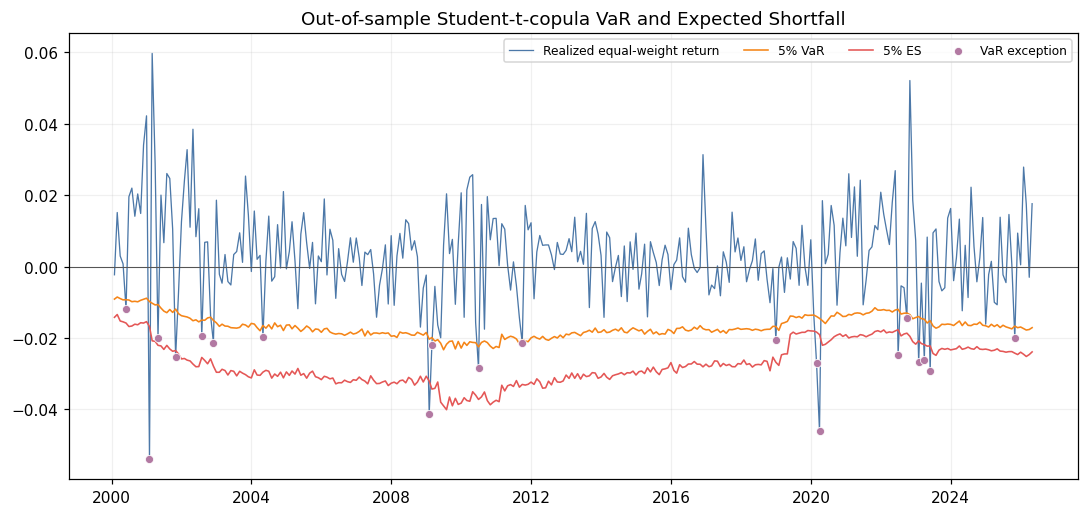

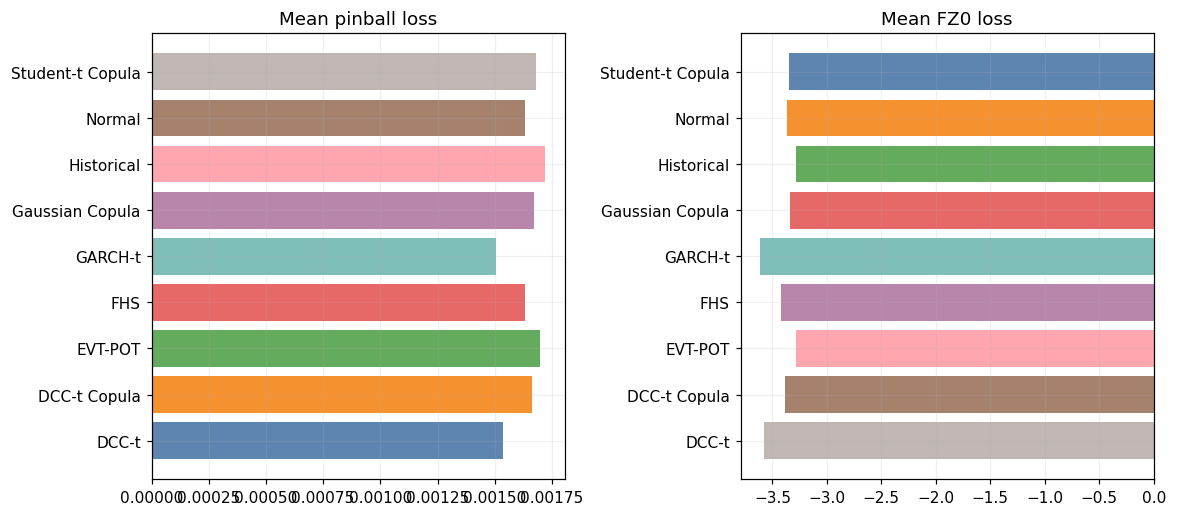

In [16]:
student = us_forecasts[us_forecasts.Model == "Student-t Copula"].copy()
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(student.index, student.Return, label="Realized equal-weight return", lw=.85, color="#4C78A8")
ax.plot(student.index, student.VaR, label="5% VaR", lw=1.05, color="#F58518")
ax.plot(student.index, student.ES, label="5% ES", lw=1.05, color="#E45756")
hit = student.Return < student.VaR
ax.scatter(
    student.index[hit], student.Return[hit], s=28, c="#B279A2",
    edgecolor="white", linewidth=.5, label="VaR exception", zorder=3
)
ax.axhline(0, lw=.7, color="#555555")
ax.legend(ncol=4, fontsize=8)
ax.set_title("Out-of-sample Student-t-copula VaR and Expected Shortfall")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "Figure_5_VaR_ES_Monitoring.png", dpi=220, bbox_inches="tight")
plt.show()

score = us_forecasts.groupby("Model")[["Pinball", "FZ0"]].mean().sort_index()
bar_colors = [CHART_COLORS[i % len(CHART_COLORS)] for i in range(len(score))]
fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.8))
axes[0].barh(score.index, score.Pinball, color=bar_colors, alpha=.9)
axes[0].set_title("Mean pinball loss")
axes[1].barh(score.index, score.FZ0, color=bar_colors[::-1], alpha=.9)
axes[1].set_title("Mean FZ0 loss")
for ax in axes:
    ax.grid(axis="x", alpha=.2)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "Figure_6_Forecast_Loss.png", dpi=220, bbox_inches="tight")
plt.show()


## 6. Portfolio allocation and ablation tests

In [17]:
def drift_weights(w, r):
    gross = np.asarray(w, float) * (1 + np.asarray(r, float))
    return gross / gross.sum() if gross.sum() > 0 else np.asarray(w, float)


def one_way_turnover(w, pre):
    return .5 * np.sum(np.abs(np.asarray(w) - np.asarray(pre)))


def scenario_es_loss(w, scenarios, alpha=.05):
    rp = np.asarray(scenarios) @ np.asarray(w)
    m = max(1, int(np.ceil(alpha * len(rp))))
    return -np.mean(np.partition(rp, m-1)[:m])


def tail_event_corr_with_threshold(x, threshold, q=.10):
    indicator = (x <= threshold).astype(float).values - q
    S = indicator.T @ indicator / len(indicator)
    d = np.sqrt(np.maximum(np.diag(S), 1e-12))
    return nearest_correlation_higham(S / np.outer(d, d))


def tail_event_corr(x, q=.10):
    return tail_event_corr_with_threshold(x, x.quantile(q), q)


def tail_corr_at_month(z_daily, end_date, window=252, q=.10, threshold_mode="rolling"):
    history = z_daily.loc[:end_date]
    x = history.tail(window)
    if len(x) < window:
        return np.eye(z_daily.shape[1])
    if threshold_mode == "rolling":
        threshold = x.quantile(q)
    elif threshold_mode == "expanding":
        threshold = history.quantile(q)
    elif threshold_mode == "fixed":
        threshold = z_daily.iloc[:min(1260, len(z_daily))].quantile(q)
    else:
        raise ValueError("threshold_mode must be rolling, expanding, or fixed")
    return tail_event_corr_with_threshold(x, threshold, q)


def solve_weights(
    mu, pre, kind, cov=None, scenarios=None, tail=None, nu=8,
    turnover_penalty=0.0, risk_aversion=10.0,
    use_return_floor=False, use_tail_cap=False,
):
    """Solve one transparent long-only portfolio problem.

    MinVar and MVO are *pure* classical benchmarks: no return floor and no turnover penalty.
    Tail-MinVar differs from MinVar only by the tail-concentration cap.
    ES rules may use a return floor and a return-scale turnover regularizer.
    """
    mu = np.asarray(mu, float)
    pre = np.asarray(pre, float)
    k = len(mu)
    equal = np.repeat(1/k, k)

    start = np.clip(pre, 0, .6)
    start = equal if start.sum() <= 0 else start / start.sum()

    constraints = [{"type": "eq", "fun": lambda w: np.sum(w) - 1}]

    if use_return_floor:
        return_floor = float(equal @ mu)
        constraints.append({"type": "ineq", "fun": lambda w, floor=return_floor: float(w @ mu - floor)})

    if use_tail_cap:
        if tail is None:
            raise ValueError("tail matrix is required when use_tail_cap=True")
        tail_cap = float(equal @ tail @ equal)
        constraints.append({
            "type": "ineq",
            "fun": lambda w, T=tail, cap=tail_cap: float(cap - w @ T @ w),
        })

    def turnover_cost(w):
        return turnover_penalty * one_way_turnover(w, pre)

    if kind == "minvar":
        objective = lambda w: float(w @ cov @ w)
    elif kind == "mvo":
        objective = lambda w: float(-w @ mu + 0.5 * risk_aversion * (w @ cov @ w))
    elif kind == "normal_es":
        multiplier = stats.norm.pdf(stats.norm.ppf(ALPHA)) / ALPHA
        objective = lambda w: float(
            -w @ mu + multiplier * np.sqrt(max(w @ cov @ w, 1e-14)) + turnover_cost(w)
        )
    elif kind == "t_es":
        q_alpha = stats.t.ppf(ALPHA, nu)
        multiplier = (
            stats.t.pdf(q_alpha, nu) * (nu + q_alpha*q_alpha)
            / ((nu-1) * ALPHA) * np.sqrt((nu-2)/nu)
        )
        objective = lambda w: float(
            -w @ mu + multiplier * np.sqrt(max(w @ cov @ w, 1e-14)) + turnover_cost(w)
        )
    elif kind == "scenario":
        objective = lambda w: float(scenario_es_loss(w, scenarios, ALPHA) + turnover_cost(w))
    else:
        raise ValueError(f"Unknown optimizer kind: {kind}")

    result = optimize.minimize(
        objective, start, method="SLSQP", bounds=[(0, .6)] * k, constraints=constraints,
        options={"maxiter": 250, "ftol": 1e-10},
    )
    if not result.success:
        result = optimize.minimize(
            objective, equal, method="SLSQP", bounds=[(0, .6)] * k, constraints=constraints,
            options={"maxiter": 500, "ftol": 1e-9},
        )

    if not result.success:
        print("Warning: optimizer fallback to 1/N for", kind, "|", result.message)
        return equal
    return np.asarray(result.x, float)


In [18]:
def run_portfolios(monthly, z_daily, scenario_cache, tail_window=252, tail_q=.10, threshold_mode="rolling"):
    dates = sorted(scenario_cache.keys())
    names = [
        "1/N", "Inverse Vol", "Vol-Managed 1/N", "MinVar", "MVO", "Historical-ES", "Normal-ES",
        "Gaussian-Copula-ES", "Student-t-Copula-ES", "DCC-t-ES", "DCC-t-Copula-ES",
        "Tail-MinVar", "Full Copula-ES",
    ]
    k = monthly.shape[1]
    equal = np.repeat(1/k, k)
    previous = {name: equal.copy() for name in names}
    eq_ret = monthly.mean(axis=1)
    target_var = float(eq_ret.iloc[:FORECAST_WINDOW].var(ddof=1))
    rows = []

    for date in dates:
        t = monthly.index.get_loc(date) - 1
        window = monthly.iloc[t-FORECAST_WINDOW+1:t+1]
        r_next = monthly.loc[date].values
        mu = window.mean().values
        cov = window.cov().values

        if z_daily is not None:
            tail = tail_corr_at_month(z_daily, monthly.index[t], tail_window, tail_q, threshold_mode)
        else:
            # Common monthly definition for international samples when daily data are not uniformly available.
            tail = tail_event_corr(window.tail(min(tail_window, len(window))), tail_q)

        cache = scenario_cache[date]
        targets = {"1/N": equal}

        inv = 1 / np.maximum(window.std().values, 1e-8)
        targets["Inverse Vol"] = inv / inv.sum()

        recent_var = float(eq_ret.iloc[max(0, t-11):t+1].var(ddof=1))
        gross = np.clip(target_var / max(recent_var, 1e-10), .25, 1.50)
        targets["Vol-Managed 1/N"] = gross * equal

        for name in names[3:]:
            if date == dates[0]:
                pre = previous[name]
            else:
                prior_date = monthly.index[monthly.index.get_loc(date)-1]
                pre = drift_weights(previous[name], monthly.loc[prior_date].values)

            if name == "MinVar":
                # Pure minimum variance: no return floor, no turnover penalty.
                targets[name] = solve_weights(mu, pre, "minvar", cov=cov)

            elif name == "MVO":
                # Classical constrained mean-variance benchmark; no return floor or turnover penalty.
                targets[name] = solve_weights(
                    mu, pre, "mvo", cov=cov, risk_aversion=MVO_RISK_AVERSION
                )

            elif name == "Historical-ES":
                targets[name] = solve_weights(
                    mu, pre, "scenario", scenarios=cache["historical"],
                    turnover_penalty=ES_TURNOVER_PENALTY, use_return_floor=True,
                )

            elif name == "Normal-ES":
                targets[name] = solve_weights(
                    mu, pre, "normal_es", cov=cov,
                    turnover_penalty=ES_TURNOVER_PENALTY, use_return_floor=True,
                )

            elif name == "Gaussian-Copula-ES":
                targets[name] = solve_weights(
                    mu, pre, "scenario", scenarios=cache["gaussian"],
                    turnover_penalty=ES_TURNOVER_PENALTY, use_return_floor=True,
                )

            elif name == "Student-t-Copula-ES":
                targets[name] = solve_weights(
                    mu, pre, "scenario", scenarios=cache["student"],
                    turnover_penalty=ES_TURNOVER_PENALTY, use_return_floor=True,
                )

            elif name == "DCC-t-ES":
                targets[name] = solve_weights(
                    mu, pre, "t_es", cov=cache["dcc_cov"], nu=cache["dcc_nu"],
                    turnover_penalty=ES_TURNOVER_PENALTY, use_return_floor=True,
                )

            elif name == "DCC-t-Copula-ES":
                targets[name] = solve_weights(
                    mu, pre, "scenario", scenarios=cache["dcc_copula"],
                    turnover_penalty=ES_TURNOVER_PENALTY, use_return_floor=True,
                )

            elif name == "Tail-MinVar":
                # Tail-MinVar differs from pure MinVar only by the PSD tail-concentration cap.
                targets[name] = solve_weights(
                    mu, pre, "minvar", cov=cov, tail=tail, use_tail_cap=True
                )

            elif name == "Full Copula-ES":
                targets[name] = solve_weights(
                    mu, pre, "scenario", scenarios=cache["student"], tail=tail,
                    turnover_penalty=ES_TURNOVER_PENALTY,
                    use_return_floor=True, use_tail_cap=True,
                )

        for name, w in targets.items():
            if date == dates[0]:
                pre = previous[name]
            else:
                prior_date = monthly.index[monthly.index.get_loc(date)-1]
                pre = drift_weights(previous[name], monthly.loc[prior_date].values)
            turn = one_way_turnover(w, pre)
            ret = float(np.asarray(w) @ r_next)
            rows.append([date, name, ret, turn, np.sum(w), *w])
            previous[name] = np.asarray(w)

    columns = ["Date", "Strategy", "GrossReturn", "Turnover", "Gross"] + list(monthly.columns)
    return pd.DataFrame(rows, columns=columns).set_index("Date")


us_portfolios = run_portfolios(us_monthly, z_daily, us_scenarios)
print("Portfolio rows:", len(us_portfolios))


Portfolio rows: 4108


,N,Ann. mean (%),Ann. vol. (%),Sharpe,Max DD (%),VaR 5% (%),ES 5% (%),Avg. turnover,Avg. gross
Strategy,,,,,,,,,
1/N,316,3.671,4.696,0.782,-12.362,-1.993,-2.785,0.012,1.000
DCC-t-Copula-ES,316,2.739,4.023,0.681,-10.033,-1.601,-2.368,0.053,1.000
DCC-t-ES,316,3.039,3.676,0.827,-8.065,-1.424,-2.106,0.050,1.000
Full Copula-ES,316,3.307,4.029,0.821,-9.041,-1.459,-2.428,0.030,1.000
Gaussian-Copula-ES,316,2.945,4.094,0.719,-8.265,-1.536,-2.345,0.020,1.000
Historical-ES,316,3.141,4.268,0.736,-10.999,-1.493,-2.488,0.024,1.000
Inverse Vol,316,3.219,4.656,0.691,-11.911,-1.767,-2.710,0.011,1.000
MVO,316,4.315,7.490,0.576,-15.009,-3.076,-5.144,0.040,1.000
MinVar,316,3.163,4.127,0.766,-10.399,-1.474,-2.473,0.014,1.000


,N,Ann. mean (%),Ann. vol. (%),Sharpe,Max DD (%),VaR 5% (%),ES 5% (%),Avg. turnover,Avg. gross
Strategy,,,,,,,,,
1/N,316,3.657,4.696,0.779,-12.380,-1.996,-2.836,0.012,1.000
DCC-t-Copula-ES,316,2.675,4.023,0.665,-10.277,-1.609,-2.375,0.053,1.000
DCC-t-ES,316,2.979,3.676,0.810,-8.208,-1.427,-2.113,0.050,1.000
Full Copula-ES,316,3.271,4.029,0.812,-9.136,-1.462,-2.431,0.030,1.000
Gaussian-Copula-ES,316,2.920,4.094,0.713,-8.301,-1.538,-2.347,0.020,1.000
Historical-ES,316,3.113,4.268,0.729,-11.056,-1.495,-2.491,0.024,1.000
Inverse Vol,316,3.205,4.655,0.688,-11.940,-1.768,-2.711,0.011,1.000
MVO,316,4.267,7.491,0.570,-15.020,-3.080,-5.148,0.040,1.000
MinVar,316,3.146,4.126,0.762,-10.420,-1.475,-2.474,0.014,1.000



Optimizer audit (all violation counts should be zero):


,Audit check,Value
0,MinVar variance violations,0.000000
1,MVO objective violations,0.000000
2,Tail-MinVar cap violations,0.000000
3,MinVar weight-sum violations,0.000000
4,MinVar lower-bound violations,0.000000
5,MinVar upper-bound violations,0.000000
6,Mean MinVar ex-ante variance improvement vs 1/N,0.000068
7,Mean MinVar turnover,0.014305


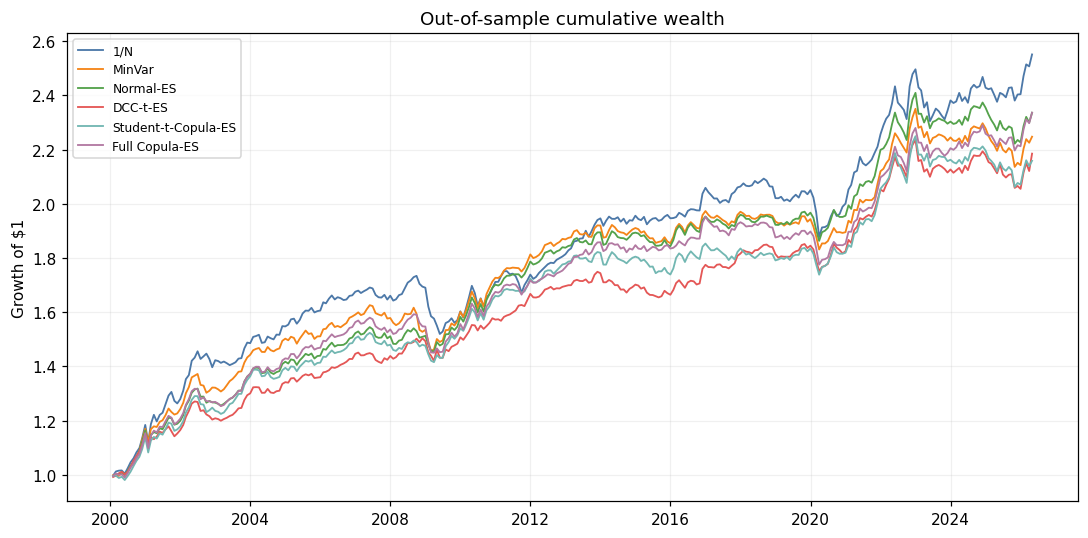

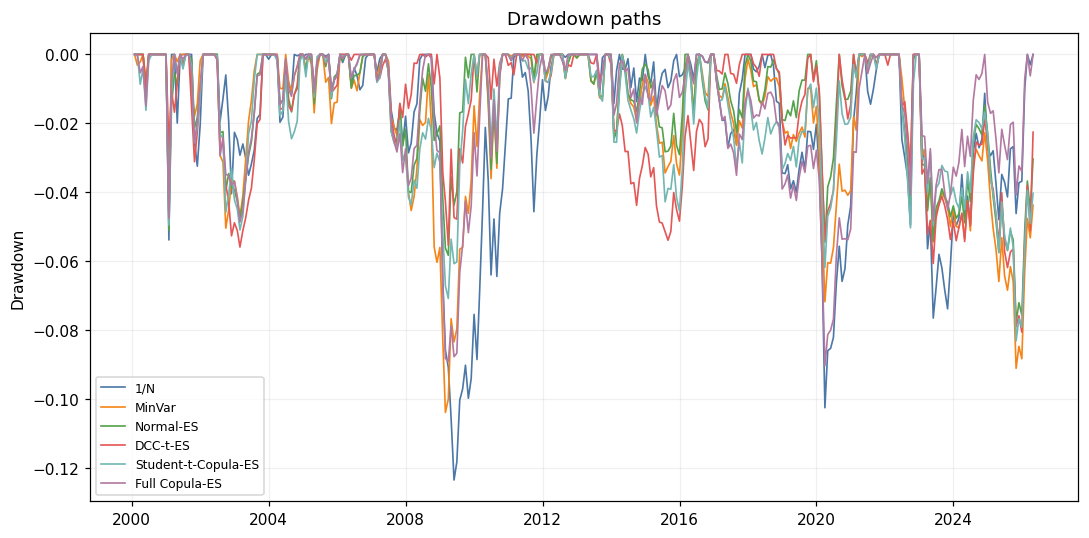

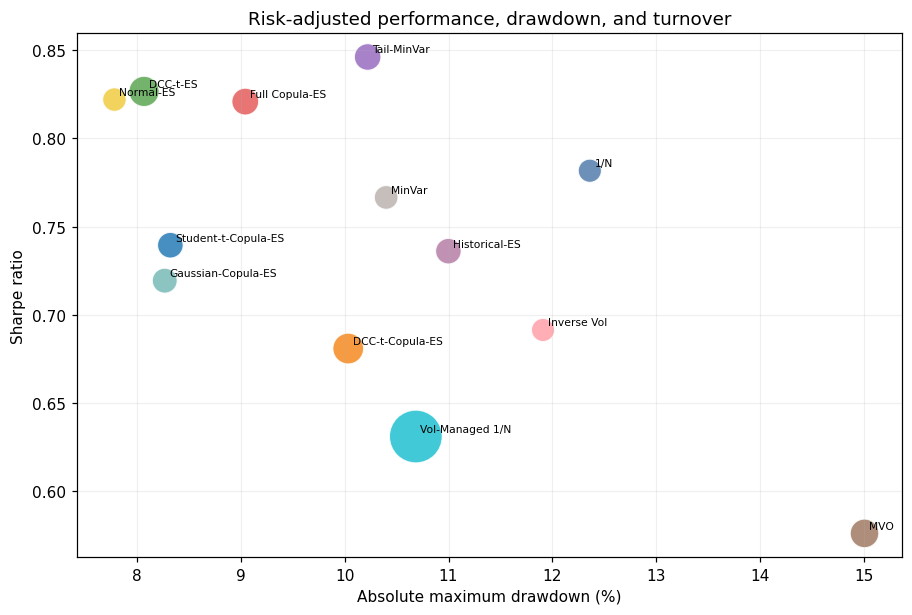

In [19]:
def portfolio_table(portfolios, cost_bp=0):
    rows = []
    for name, g in portfolios.groupby("Strategy"):
        net = g.GrossReturn - (cost_bp/10000) * g.Turnover
        stats_row = performance_stats(net, ALPHA)
        stats_row.update({
            "Strategy": name,
            "Avg. turnover": g.Turnover.mean(),
            "Avg. gross": g.Gross.mean(),
        })
        rows.append(stats_row)
    return pd.DataFrame(rows).set_index("Strategy")


def optimizer_audit(portfolios, monthly, z_daily):
    """Mechanical checks that prevent weakened benchmark implementations.

    Because 1/N is feasible for MinVar, each MinVar solution must have ex-ante variance
    no greater than 1/N under the same rolling covariance matrix. Similar checks are made
    for the MVO objective and Tail-MinVar tail cap.
    """
    equal = np.repeat(1/monthly.shape[1], monthly.shape[1])
    rows = []

    for date in sorted(portfolios.index.unique()):
        t = monthly.index.get_loc(date) - 1
        window = monthly.iloc[t-FORECAST_WINDOW+1:t+1]
        mu = window.mean().values
        cov = window.cov().values
        tail = tail_corr_at_month(z_daily, monthly.index[t], TDI_WINDOW, TAIL_Q, "rolling")

        row_min = portfolios[(portfolios.index == date) & (portfolios.Strategy == "MinVar")].iloc[0]
        row_mvo = portfolios[(portfolios.index == date) & (portfolios.Strategy == "MVO")].iloc[0]
        row_tail = portfolios[(portfolios.index == date) & (portfolios.Strategy == "Tail-MinVar")].iloc[0]
        w_min = row_min[FACTORS].values.astype(float)
        w_mvo = row_mvo[FACTORS].values.astype(float)
        w_tail = row_tail[FACTORS].values.astype(float)

        var_equal = float(equal @ cov @ equal)
        var_min = float(w_min @ cov @ w_min)
        mvo_equal = float(-equal @ mu + .5*MVO_RISK_AVERSION*(equal @ cov @ equal))
        mvo_value = float(-w_mvo @ mu + .5*MVO_RISK_AVERSION*(w_mvo @ cov @ w_mvo))
        tail_cap = float(equal @ tail @ equal)
        tail_value = float(w_tail @ tail @ w_tail)

        rows.append({
            "Date": date,
            "1/N ex-ante variance": var_equal,
            "MinVar ex-ante variance": var_min,
            "MinVar variance gap vs 1/N": var_min-var_equal,
            "MinVar sum error": abs(w_min.sum()-1),
            "MinVar min weight": w_min.min(),
            "MinVar max weight": w_min.max(),
            "MVO objective gap vs 1/N": mvo_value-mvo_equal,
            "Tail-MinVar concentration gap vs 1/N cap": tail_value-tail_cap,
            "MinVar turnover": float(row_min.Turnover),
            "Tail-MinVar turnover": float(row_tail.Turnover),
        })

    audit = pd.DataFrame(rows).set_index("Date")
    tol = 1e-8
    summary = pd.DataFrame({
        "Audit check": [
            "MinVar variance violations", "MVO objective violations", "Tail-MinVar cap violations",
            "MinVar weight-sum violations", "MinVar lower-bound violations", "MinVar upper-bound violations",
            "Mean MinVar ex-ante variance improvement vs 1/N", "Mean MinVar turnover",
        ],
        "Value": [
            int((audit["MinVar variance gap vs 1/N"] > tol).sum()),
            int((audit["MVO objective gap vs 1/N"] > tol).sum()),
            int((audit["Tail-MinVar concentration gap vs 1/N cap"] > tol).sum()),
            int((audit["MinVar sum error"] > tol).sum()),
            int((audit["MinVar min weight"] < -tol).sum()),
            int((audit["MinVar max weight"] > .60000001).sum()),
            float(-audit["MinVar variance gap vs 1/N"].mean()),
            float(audit["MinVar turnover"].mean()),
        ],
    })

    hard_fail = summary.loc[summary["Audit check"].str.contains("violations"), "Value"].sum()
    if hard_fail > 0:
        raise RuntimeError("Optimizer audit failed. Inspect benchmark_optimizer_audit.csv before using portfolio results.")
    return audit, summary


gross_table = portfolio_table(us_portfolios, 0)
net10_table = portfolio_table(us_portfolios, 10)
gross_table.to_csv(TABLE_DIR / "Table_8A_Portfolio_Gross_Performance.csv")
net10_table.to_csv(TABLE_DIR / "Table_8B_Portfolio_Net_10bp.csv")
display(gross_table.round(3))
display(net10_table.round(3))

benchmark_audit, benchmark_audit_summary = optimizer_audit(us_portfolios, us_monthly, z_daily)
benchmark_audit.to_csv(TABLE_DIR / "benchmark_optimizer_audit.csv")
benchmark_audit_summary.to_csv(TABLE_DIR / "benchmark_optimizer_audit_summary.csv", index=False)
print("\nOptimizer audit (all violation counts should be zero):")
display(benchmark_audit_summary)

selected = ["1/N", "MinVar", "Normal-ES", "DCC-t-ES", "Student-t-Copula-ES", "Full Copula-ES"]
fig, ax = plt.subplots(figsize=(10, 5))
for i, name in enumerate(selected):
    r = us_portfolios[us_portfolios.Strategy == name].GrossReturn
    ax.plot(r.index, (1+r).cumprod(), label=name, color=CHART_COLORS[i], lw=1.2)
ax.legend(fontsize=8)
ax.set_title("Out-of-sample cumulative wealth")
ax.set_ylabel("Growth of $1")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "Figure_7_Cumulative_Wealth.png", dpi=220, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
for i, name in enumerate(selected):
    r = us_portfolios[us_portfolios.Strategy == name].GrossReturn
    wealth = (1+r).cumprod()
    dd = wealth/wealth.cummax()-1
    ax.plot(dd.index, dd, label=name, color=CHART_COLORS[i], lw=1.1)
ax.legend(fontsize=8)
ax.set_title("Drawdown paths")
ax.set_ylabel("Drawdown")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "Figure_8_Drawdowns.png", dpi=220, bbox_inches="tight")
plt.show()

plot = gross_table.copy()
plot["Abs DD"] = plot["Max DD (%)"].abs()
fig, ax = plt.subplots(figsize=(8.4, 5.7))
size = 180 + 4200*plot["Avg. turnover"]
scatter_colors = [CHART_COLORS[i % len(CHART_COLORS)] for i in range(len(plot))]
ax.scatter(
    plot["Abs DD"], plot["Sharpe"], s=size, c=scatter_colors,
    alpha=.82, edgecolor="white", linewidth=.7
)
for name, row in plot.iterrows():
    ax.annotate(name, (row["Abs DD"], row["Sharpe"]), fontsize=7, xytext=(3, 3), textcoords="offset points")
ax.set_xlabel("Absolute maximum drawdown (%)")
ax.set_ylabel("Sharpe ratio")
ax.set_title("Risk-adjusted performance, drawdown, and turnover")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "Figure_9_Risk_Return_Map.png", dpi=220, bbox_inches="tight")
plt.show()


## 7. Portfolio inference, transaction costs, and event/subperiod robustness

In [20]:
def block_resample_pair(a, b, B=1999, block=12, seed=123):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    n = len(a)
    rng = np.random.default_rng(seed)
    out = []
    for _ in range(B):
        idx = circular_block_indices(n, block, rng)
        out.append((a[idx], b[idx]))
    return out


def sharpe_monthly(r):
    r = np.asarray(r, float)
    return np.mean(r) / np.std(r, ddof=1) * np.sqrt(12)


def hac_sharpe_difference(a, b, lags=HAC_LAGS):
    a, b = np.asarray(a, float), np.asarray(b, float)
    X = np.column_stack([a, a*a, b, b*b])
    means = X.mean(0)
    centered = X-means
    n = len(X)
    S = centered.T @ centered / n
    for lag in range(1, lags+1):
        weight = 1-lag/(lags+1)
        G = centered[lag:].T @ centered[:-lag] / n
        S += weight*(G+G.T)

    def grad(mu, m2):
        var = max(m2-mu*mu, 1e-12)
        sd = np.sqrt(var)
        return np.array([1/sd+mu*mu/(sd**3), -mu/(2*sd**3)]) * np.sqrt(12)

    g = np.r_[grad(means[0], means[1]), -grad(means[2], means[3])]
    diff = sharpe_monthly(a)-sharpe_monthly(b)
    se = np.sqrt(max(g @ S @ g / n, 1e-16))
    z = diff/se
    return diff, float(z), float(2*stats.norm.sf(abs(z)))


def downside_inference(full, benchmark, B=1999, seed=123):
    """Paired circular-block inference.

    ES and MDD p-values are one-sided because the directional hypothesis is that
    Full Copula-ES has lower downside risk than the named benchmark.
    """
    pairs = block_resample_pair(full, benchmark, B, 12, seed)
    sharpe, es_imp, dd_imp = [], [], []
    for a, b in pairs:
        sharpe.append(sharpe_monthly(a)-sharpe_monthly(b))
        qa, qb = np.quantile(a, ALPHA), np.quantile(b, ALPHA)
        esa, esb = a[a <= qa].mean(), b[b <= qb].mean()
        es_imp.append(100*((-esb)-(-esa)))
        dd_imp.append(100*(abs(max_drawdown(b))-abs(max_drawdown(a))))
    sharpe = np.asarray(sharpe)
    es_imp = np.asarray(es_imp)
    dd_imp = np.asarray(dd_imp)
    return {
        "Sharpe CI low": np.quantile(sharpe, .025),
        "Sharpe CI high": np.quantile(sharpe, .975),
        "ES one-sided boot p": np.mean(es_imp <= 0),
        "MDD one-sided boot p": np.mean(dd_imp <= 0),
    }


full = us_portfolios[us_portfolios.Strategy == "Full Copula-ES"].GrossReturn
comparators = [
    "1/N", "MinVar", "Vol-Managed 1/N", "Historical-ES", "Normal-ES", "Gaussian-Copula-ES",
    "Student-t-Copula-ES", "DCC-t-ES", "DCC-t-Copula-ES", "Tail-MinVar",
]
rows = []
for j, name in enumerate(comparators):
    bench = us_portfolios[us_portfolios.Strategy == name].GrossReturn
    diff, z, p = hac_sharpe_difference(full.values, bench.values, HAC_LAGS)
    inf = downside_inference(full.values, bench.values, PORTFOLIO_BOOTSTRAPS, RANDOM_SEED+100+j)
    full_stats, bench_stats = performance_stats(full), performance_stats(bench)
    rows.append([
        name, diff, inf["Sharpe CI low"], inf["Sharpe CI high"], p,
        abs(bench_stats["ES 5% (%)"])-abs(full_stats["ES 5% (%)"]), inf["ES one-sided boot p"],
        abs(bench_stats["Max DD (%)"])-abs(full_stats["Max DD (%)"]), inf["MDD one-sided boot p"],
    ])

table9 = pd.DataFrame(rows, columns=[
    "Benchmark", "Delta Sharpe", "95% CI low", "95% CI high", "HAC p",
    "ES improvement (pp)", "ES one-sided boot p", "MDD improvement (pp)", "MDD one-sided boot p",
])
# Adjust across the benchmark family; raw one-sided p-values remain visible for transparency.
table9["ES FDR q"] = multipletests(table9["ES one-sided boot p"].values, method="fdr_bh")[1]
table9["MDD FDR q"] = multipletests(table9["MDD one-sided boot p"].values, method="fdr_bh")[1]
table9["Sharpe FDR q"] = multipletests(table9["HAC p"].values, method="fdr_bh")[1]
table9.to_csv(TABLE_DIR / "Table_9_Portfolio_Inference.csv", index=False)
display(table9.round(3))

cost_rows = []
for cost in [0, 10, 25, 50]:
    temp = portfolio_table(us_portfolios, cost)
    for name in ["1/N", "MinVar", "DCC-t-ES", "Full Copula-ES", "Normal-ES", "Student-t-Copula-ES", "Tail-MinVar"]:
        r = temp.loc[name]
        cost_rows.append([cost, name, r["Ann. mean (%)"], r["Sharpe"], r["Max DD (%)"], r["ES 5% (%)"]])
table_a3 = pd.DataFrame(
    cost_rows,
    columns=["Cost (bp)", "Strategy", "Ann. mean (%)", "Sharpe", "Max DD (%)", "ES 5% (%)"],
)
table_a3.to_csv(TABLE_DIR / "Appendix_Table_A3_Transaction_Costs.csv", index=False)
display(table_a3.round(3))


,Benchmark,Delta Sharpe,95% CI low,95% CI high,HAC p,ES improvement (pp),ES one-sided boot p,MDD improvement (pp),MDD one-sided boot p,ES FDR q,MDD FDR q,Sharpe FDR q
0,1/N,0.039,-0.124,0.199,0.622,0.357,0.002,3.321,0.069,0.020,0.690,0.777
1,MinVar,0.054,-0.110,0.230,0.513,0.045,0.417,1.358,0.322,0.893,0.769,0.733
2,Vol-Managed 1/N,0.190,-0.066,0.438,0.140,-0.433,0.939,1.644,0.585,0.948,0.769,0.700
3,Historical-ES,0.085,-0.140,0.298,0.447,0.060,0.398,1.957,0.633,0.893,0.769,0.733
4,Normal-ES,-0.001,-0.171,0.161,0.989,-0.128,0.714,-1.261,0.769,0.893,0.769,0.989
5,Gaussian-Copula-ES,0.101,-0.065,0.276,0.224,-0.083,0.617,-0.776,0.637,0.893,0.769,0.733
6,Student-t-Copula-ES,0.081,-0.107,0.267,0.382,-0.117,0.706,-0.722,0.664,0.893,0.769,0.733
7,DCC-t-ES,-0.006,-0.208,0.181,0.955,-0.322,0.948,-0.976,0.715,0.948,0.769,0.989
8,DCC-t-Copula-ES,0.140,-0.009,0.300,0.101,-0.061,0.608,0.992,0.283,0.893,0.769,0.700
9,Tail-MinVar,-0.025,-0.107,0.047,0.505,0.070,0.290,1.179,0.156,0.893,0.769,0.733


,Cost (bp),Strategy,Ann. mean (%),Sharpe,Max DD (%),ES 5% (%)
0,0,1/N,3.671,0.782,-12.362,-2.785
1,0,MinVar,3.163,0.766,-10.399,-2.473
2,0,DCC-t-ES,3.039,0.827,-8.065,-2.106
3,0,Full Copula-ES,3.307,0.821,-9.041,-2.428
4,0,Normal-ES,3.306,0.822,-7.780,-2.300
5,0,Student-t-Copula-ES,3.007,0.739,-8.319,-2.311
6,0,Tail-MinVar,3.436,0.846,-10.220,-2.498
7,10,1/N,3.657,0.779,-12.380,-2.836
8,10,MinVar,3.146,0.762,-10.420,-2.474
9,10,DCC-t-ES,2.979,0.810,-8.208,-2.113


In [21]:
periods = {
    "Pre-GFC": ("2000-01-31", "2007-12-31"),
    "GFC": ("2008-01-31", "2009-12-31"),
    "Post-GFC pre-COVID": ("2010-01-31", "2019-12-31"),
    "COVID shock": ("2020-01-31", "2020-12-31"),
    "Post-COVID": ("2021-01-31", "2026-04-30"),
}
rows = []
for label, (start, end) in periods.items():
    for name in ["1/N", "MinVar", "Normal-ES", "DCC-t-ES", "Student-t-Copula-ES", "Full Copula-ES"]:
        r = us_portfolios[us_portfolios.Strategy == name].GrossReturn.loc[start:end]
        s = performance_stats(r)
        rows.append([label, name, len(r), s["Sharpe"], s["Max DD (%)"], s["ES 5% (%)"]])
table10 = pd.DataFrame(rows, columns=["Period", "Strategy", "Months", "Sharpe", "Max DD (%)", "ES 5% (%)"])
table10.to_csv(TABLE_DIR / "Table_10_Subperiod_Event_Performance.csv", index=False)
display(table10.round(3))


def run_full_strategy_variant(window, q, mode):
    dates = sorted(us_scenarios.keys())
    equal = np.repeat(1/6, 6)
    previous = equal.copy()
    returns = []

    for date in dates:
        t = us_monthly.index.get_loc(date)-1
        hist = us_monthly.iloc[t-FORECAST_WINDOW+1:t+1]
        pre = previous if date == dates[0] else drift_weights(previous, us_monthly.iloc[t].values)
        tail = tail_corr_at_month(z_daily, us_monthly.index[t], window, q, mode)
        w = solve_weights(
            hist.mean().values, pre, "scenario", scenarios=us_scenarios[date]["student"], tail=tail,
            turnover_penalty=ES_TURNOVER_PENALTY, use_return_floor=True, use_tail_cap=True,
        )
        returns.append(float(w @ us_monthly.loc[date].values))
        previous = w
    return pd.Series(returns, index=dates)


# Use exactly the same eight specifications already subjected to HAC and signal-reconstruction bootstrap inference.
robust_rows = []
for label, window, q, mode in CRASH_SPECS:
    s = tdi_spec_series[label]
    pair = pd.concat([tdi_daily.resample("ME").last().rename("base"), s.rename("alt")], axis=1).dropna()
    full_variant = run_full_strategy_variant(window, q, mode)
    perf = performance_stats(full_variant)
    inference = crash_spec_table.loc[crash_spec_table["Specification"] == label].iloc[0]
    robust_rows.append([
        label, mode, window, q, s.dropna().mean(), s.dropna().std(), s.dropna().min(), s.dropna().max(),
        pair.corr().iloc[0, 1], inference["TDI beta"], inference["HAC p (12)"], inference["Bootstrap p"],
        inference["HAC FDR q (all eight)"], inference["Bootstrap FDR q (all eight)"],
        perf["Sharpe"], perf["Max DD (%)"], perf["ES 5% (%)"],
    ])

table_a4 = pd.DataFrame(robust_rows, columns=[
    "Specification", "Threshold mode", "Window", "q", "Mean TDI", "Std TDI", "Min TDI", "Max TDI",
    "Correlation with baseline", "Full-state LPM beta", "HAC p (12)", "Reconstruction bootstrap p",
    "HAC FDR q (all eight)", "Bootstrap FDR q (all eight)",
    "Full Copula-ES Sharpe", "Max DD (%)", "ES 5% (%)",
])
table_a4.to_csv(TABLE_DIR / "Appendix_Table_A4_TDI_Crash_and_Allocation_Robustness.csv", index=False)
display(table_a4.round(3))


,Period,Strategy,Months,Sharpe,Max DD (%),ES 5% (%)
0,Pre-GFC,1/N,96,1.224,-5.388,-2.801
1,Pre-GFC,MinVar,96,1.319,-5.046,-2.412
2,Pre-GFC,Normal-ES,96,1.192,-5.110,-2.577
3,Pre-GFC,DCC-t-ES,96,1.240,-5.595,-1.993
4,Pre-GFC,Student-t-Copula-ES,96,1.100,-5.097,-2.680
5,Pre-GFC,Full Copula-ES,96,1.236,-4.866,-2.539
6,GFC,1/N,24,-0.326,-12.362,-3.157
7,GFC,MinVar,24,0.158,-9.885,-3.268
8,GFC,Normal-ES,24,0.538,-5.577,-2.006
9,GFC,DCC-t-ES,24,0.540,-5.543,-2.403


,Specification,Threshold mode,Window,q,Mean TDI,Std TDI,Min TDI,Max TDI,Correlation with baseline,Full-state LPM beta,HAC p (12),Reconstruction bootstrap p,HAC FDR q (all eight),Bootstrap FDR q (all eight),Full Copula-ES Sharpe,Max DD (%),ES 5% (%)
0,Rolling W126 q05,rolling,126,0.05,0.073,0.054,-0.018,0.246,0.736,0.052,0.013,0.104,0.035,0.305,0.822,-9.881,-2.443
1,Rolling W126 q10,rolling,126,0.10,0.057,0.050,-0.026,0.244,0.822,0.061,0.002,0.092,0.018,0.305,0.795,-8.917,-2.418
2,Rolling W252 q05,rolling,252,0.05,0.064,0.045,-0.013,0.215,0.891,0.059,0.008,0.248,0.034,0.331,0.814,-10.120,-2.452
3,Baseline W252 q10,rolling,252,0.10,0.058,0.044,-0.021,0.212,1.000,0.043,0.073,0.228,0.098,0.331,0.821,-9.041,-2.428
4,Rolling W504 q05,rolling,504,0.05,0.064,0.038,0.011,0.162,0.767,0.041,0.038,0.429,0.072,0.429,0.825,-10.587,-2.467
5,Rolling W504 q10,rolling,504,0.10,0.055,0.035,0.001,0.135,0.811,0.040,0.045,0.381,0.072,0.429,0.808,-9.658,-2.459
6,Expanding W252 q10,expanding,252,0.10,0.051,0.049,-0.023,0.228,0.923,0.025,0.191,0.152,0.219,0.305,0.818,-8.855,-2.420
7,Fixed W252 q10,fixed,252,0.10,0.050,0.048,-0.026,0.215,0.912,0.022,0.233,0.152,0.233,0.305,0.824,-8.825,-2.427


## 8. External 25-portfolio validation

In [22]:
z25,_,_=ewma_filter(port25_daily.dropna(axis=1,how="all"),EWMA_DECAY)
tdi25=rolling_tdi(z25,TDI_WINDOW,TAIL_Q,centered=True).resample("ME").last()
ext_ret=port25_monthly.mean(axis=1)
ext_cut=ext_ret.expanding(60).quantile(.10)
ext_future=ext_ret.shift(-1)
ext_crash=(ext_future<=ext_cut).astype(float)
ext_crash[ext_future.isna()]=np.nan

external=pd.DataFrame({"Crash":ext_crash,"TDI6":tdi_monthly.reindex(ext_ret.index),"TDI25":tdi25.reindex(ext_ret.index)})
for c in ["TDI6","TDI25"]:
    external[c+"z"]=(external[c]-external[c].expanding(12).mean())/external[c].expanding(12).std(ddof=1)
external=external.dropna()

corr=external[["TDI6","TDI25"]].corr().iloc[0,1]
rows=[["Correlation TDI6-TDI25",corr,np.nan,np.nan]]
for col in ["TDI6z","TDI25z"]:
    m=ols_hac(external.Crash, external[[col]], HAC_LAGS)
    rows.append([f"{col} predicts external crash",m.params[col],m.tvalues[col],m.pvalues[col]])
table11=pd.DataFrame(rows,columns=["Test","Estimate","HAC t","p"])
table11.to_csv(TABLE_DIR/"Table_11_External_Validation.csv",index=False)
display(table11.round(4))


,Test,Estimate,HAC t,p
0,Correlation TDI6-TDI25,0.1115,NaN,NaN
1,TDI6z predicts external crash,0.0197,1.1660,0.2436
2,TDI25z predicts external crash,0.0097,0.5554,0.5786


## 9. International out-of-sample replication

,Region,Forecast model,N,Exception rate,Kupiec p,Independence p,Pinball,FZ0
0,Developed,Historical,306,6.8627,0.1560,0.0095,0.0013,-3.7209
1,Developed,Normal,306,7.5163,0.0593,0.0040,0.0012,-3.7615
2,Developed,FHS,306,5.5556,0.6611,0.0662,0.0012,-3.8257
3,Developed,EVT-POT,306,7.1895,0.0981,0.0151,0.0013,-3.7015
4,Developed,Gaussian Copula,306,6.5359,0.2381,0.0058,0.0012,-3.7761
5,Developed,Student-t Copula,306,6.5359,0.2381,0.0058,0.0012,-3.7649
6,Emerging,Historical,286,5.5944,0.6506,0.0556,0.0012,-3.9178
7,Emerging,Normal,286,4.5455,0.7204,0.1222,0.0011,-3.9528
8,Emerging,FHS,286,5.2448,0.8505,0.8094,0.0012,-3.9385
9,Emerging,EVT-POT,286,3.8462,0.3515,0.0595,0.0011,-3.9587


,Region,Allocation,N,Sharpe,Max DD (%),ES 5% (%)
0,Developed,1/N,306,1.108,-9.067,-2.016
1,Developed,Full Tail-Aware,306,1.050,-10.729,-1.881
2,Developed,Gaussian-Copula-ES,306,1.059,-9.067,-1.735
3,Developed,Historical-ES,306,0.959,-10.304,-1.839
4,Developed,Student-t-Copula-ES,306,1.068,-8.229,-1.699
5,Emerging,1/N,286,1.650,-8.977,-1.742
6,Emerging,Full Tail-Aware,286,1.688,-7.128,-1.535
7,Emerging,Gaussian-Copula-ES,286,1.603,-4.057,-1.287
8,Emerging,Historical-ES,286,1.595,-3.745,-1.354
9,Emerging,Student-t-Copula-ES,286,1.587,-4.151,-1.292


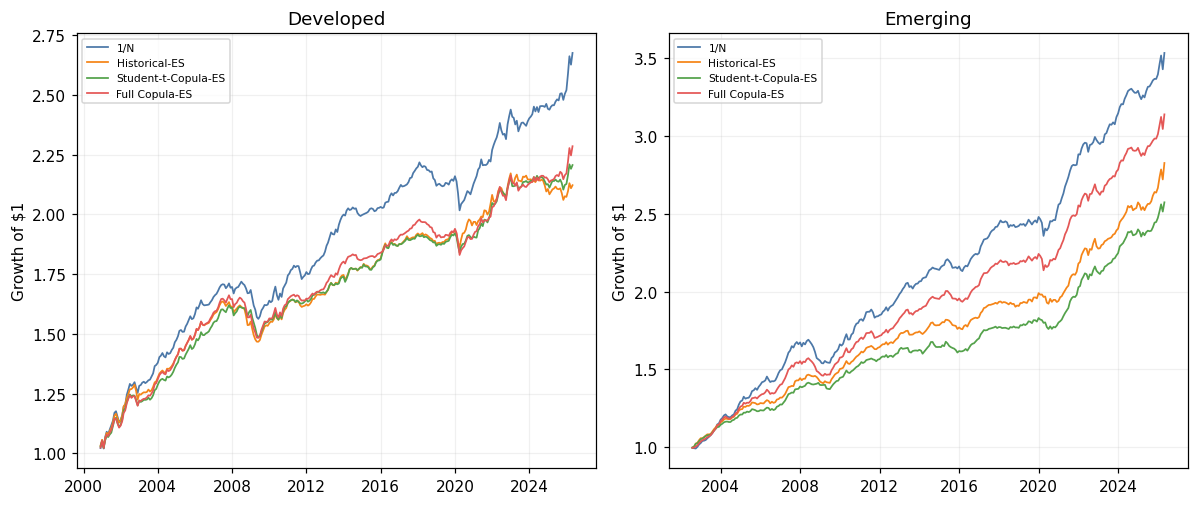

In [23]:
def compact_forecast_table(forecasts, region):
    rows = []
    models = ["Historical", "Normal", "FHS", "EVT-POT", "Gaussian Copula", "Student-t Copula"]
    for model in models:
        g = forecasts[forecasts.Model == model].copy()
        g["Pinball"] = pinball(g.Return.values, g.VaR.values, ALPHA)
        g["FZ0"] = fz0(g.Return.values, g.VaR.values, g.ES.values, ALPHA)
        hit = (g.Return < g.VaR).astype(int).values
        kup, _ = kupiec_p(hit, ALPHA)
        ind, _ = christoffersen_independence(hit)
        rows.append([region, model, len(g), 100*hit.mean(), kup, ind, g.Pinball.mean(), g.FZ0.mean()])
    return rows


def compact_allocation_table(portfolios, region):
    rows = []
    name_map = {"Full Copula-ES": "Full Tail-Aware"}
    for name in ["1/N", "Full Copula-ES", "Gaussian-Copula-ES", "Historical-ES", "Student-t-Copula-ES"]:
        r = portfolios[portfolios.Strategy == name].GrossReturn
        s = performance_stats(r)
        rows.append([region, name_map.get(name, name), len(r), s["Sharpe"], s["Max DD (%)"], s["ES 5% (%)"]])
    return rows


# Use the same recursive monthly tail-event-matrix definition for both regions so the international comparison
# does not change the tail-matrix construction merely because emerging-market daily inputs are unavailable.
dev_forecasts, dev_cache = forecast_panel(developed_monthly, N_SIM)
dev_portfolios = run_portfolios(developed_monthly, None, dev_cache)
em_forecasts, em_cache = forecast_panel(emerging_monthly, N_SIM)
em_portfolios = run_portfolios(emerging_monthly, None, em_cache)

forecast_rows = compact_forecast_table(dev_forecasts, "Developed") + compact_forecast_table(em_forecasts, "Emerging")
allocation_rows = compact_allocation_table(dev_portfolios, "Developed") + compact_allocation_table(em_portfolios, "Emerging")

table12a = pd.DataFrame(forecast_rows, columns=["Region", "Forecast model", "N", "Exception rate", "Kupiec p", "Independence p", "Pinball", "FZ0"])
table12b = pd.DataFrame(allocation_rows, columns=["Region", "Allocation", "N", "Sharpe", "Max DD (%)", "ES 5% (%)"])
table12a.to_csv(TABLE_DIR / "Table_12A_International_Forecasting.csv", index=False)
table12b.to_csv(TABLE_DIR / "Table_12B_International_Allocation.csv", index=False)
display(table12a.round(4))
display(table12b.round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.7))
intl_names = ["1/N", "Historical-ES", "Student-t-Copula-ES", "Full Copula-ES"]
for ax, (region, pf) in zip(axes, [("Developed", dev_portfolios), ("Emerging", em_portfolios)]):
    for i, name in enumerate(intl_names):
        r = pf[pf.Strategy == name].GrossReturn
        ax.plot(r.index, (1+r).cumprod(), label=name, color=CHART_COLORS[i], lw=1.15)
    ax.set_title(region)
    ax.set_ylabel("Growth of $1")
    ax.legend(fontsize=7)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "Figure_10_International_Robustness.png", dpi=220, bbox_inches="tight")
plt.show()


## 10. Nested estimation-uncertainty bootstrap

This appendix-level diagnostic propagates estimation uncertainty through the forecast and allocation stages. It is intentionally heavier than the primary inference: each outer replication resamples every 120-month estimation window in 12-month circular blocks, rebuilds the Student-t copula, resamples/re-filters the contemporaneous 252-day tail window in 20-day blocks, and re-solves Full Copula-ES weights. The final manuscript reports 99 outer replications with 128 scrambled Sobol scenarios per origin.

In [24]:
# ============================================================
# 10. Nested estimation-uncertainty bootstrap
# Stable adaptive CVaR optimizer
# ============================================================

import time


def nested_constraints(mu, tail):
    """Common portfolio constraints used inside the nested bootstrap."""
    mu = np.asarray(mu, float)
    tail = np.asarray(tail, float)

    k = len(mu)
    equal = np.repeat(1 / k, k)

    return_floor = float(equal @ mu)
    tail_cap = float(equal @ tail @ equal)

    return equal, return_floor, tail_cap


def nested_feasible(w, mu, tail, tol=1e-7):
    """Check that a candidate portfolio satisfies all nested-bootstrap constraints."""
    w = np.asarray(w, float)
    equal, return_floor, tail_cap = nested_constraints(mu, tail)

    checks = [
        abs(w.sum() - 1.0) <= 5e-6,
        w.min() >= -tol,
        w.max() <= 0.600001,
        float(w @ mu) >= return_floor - 5e-7,
        float(w @ tail @ w) <= tail_cap + 5e-7,
    ]

    return all(checks)


def analytical_t_es_weights(mu, pre, scenarios, tail, nu):
    """
    Smooth Student-t ES optimizer used only as a recovery / warm-start step.

    It uses the same:
      - long-only constraint
      - 60% weight cap
      - equal-weight expected-return floor
      - equal-weight tail-concentration cap
      - turnover regularization

    as the exact scenario-CVaR problem.
    """
    mu = np.asarray(mu, float)
    pre = np.asarray(pre, float)
    scenarios = np.asarray(scenarios, float)
    tail = np.asarray(tail, float)

    k = len(mu)
    equal, return_floor, tail_cap = nested_constraints(mu, tail)

    cov = np.cov(scenarios, rowvar=False)

    # Variance-standardised Student-t ES multiplier
    nu = max(float(nu), 2.05)
    q_alpha = stats.t.ppf(ALPHA, nu)

    multiplier = (
        stats.t.pdf(q_alpha, nu)
        * (nu + q_alpha**2)
        / ((nu - 1) * ALPHA)
        * np.sqrt((nu - 2) / nu)
    )

    def objective(w):
        variance = max(float(w @ cov @ w), 1e-14)
        expected_loss = -float(w @ mu)
        tail_risk = multiplier * np.sqrt(variance)
        turnover = ES_TURNOVER_PENALTY * one_way_turnover(w, pre)

        return expected_loss + tail_risk + turnover

    constraints = [
        {
            "type": "eq",
            "fun": lambda w: float(np.sum(w) - 1.0),
        },
        {
            "type": "ineq",
            "fun": lambda w, floor=return_floor:
                float(w @ mu - floor),
        },
        {
            "type": "ineq",
            "fun": lambda w, T=tail, cap=tail_cap:
                float(cap - w @ T @ w),
        },
    ]

    # Equal weight is feasible by construction and is therefore
    # a reliable starting point for the recovery optimizer.
    result = optimize.minimize(
        objective,
        equal,
        method="SLSQP",
        bounds=[(0.0, 0.60)] * k,
        constraints=constraints,
        options={
            "maxiter": 180,
            "ftol": 1e-9,
            "disp": False,
        },
    )

    success = (
        result.success
        and np.all(np.isfinite(result.x))
        and nested_feasible(result.x, mu, tail)
    )

    if success:
        return np.asarray(result.x, float), True

    return equal.copy(), False


def scenario_cvar_weights(
    mu,
    pre,
    scenarios,
    tail,
    nu,
):
    """
    Adaptive two-stage nested optimizer.

    Step 1
    ------
    Solve exact Rockafellar-Uryasev scenario CVaR from the previous
    portfolio (or equal weight if the previous portfolio is infeasible).

    Step 2, only if Step 1 fails
    ----------------------------
    Obtain a stable analytical Student-t ES solution and use it as a
    warm start for a second exact scenario-CVaR optimization.

    Final fallback
    --------------
    If exact scenario CVaR still fails, retain the feasible analytical
    Student-t ES solution rather than mechanically reverting to 1/N.
    """
    mu = np.asarray(mu, float)
    pre = np.asarray(pre, float)
    scenarios = np.asarray(scenarios, float)
    tail = np.asarray(tail, float)

    k = len(mu)
    equal, return_floor, tail_cap = nested_constraints(mu, tail)

    # --------------------------------------------------------
    # Rockafellar-Uryasev CVaR objective
    #
    # loss_s(w) = -r_s'w
    #
    # CVaR_alpha =
    # eta + 1/(alpha*S) sum max(loss_s - eta, 0)
    # --------------------------------------------------------

    def cvar_objective(x):
        w = x[:k]
        eta = x[-1]

        losses = -(scenarios @ w)

        cvar = (
            eta
            + np.mean(np.maximum(losses - eta, 0.0)) / ALPHA
        )

        turnover = (
            ES_TURNOVER_PENALTY
            * one_way_turnover(w, pre)
        )

        return float(cvar + turnover)

    constraints = [
        {
            "type": "eq",
            "fun": lambda x:
                float(np.sum(x[:k]) - 1.0),
        },
        {
            "type": "ineq",
            "fun": lambda x, floor=return_floor:
                float(x[:k] @ mu - floor),
        },
        {
            "type": "ineq",
            "fun": lambda x, T=tail, cap=tail_cap:
                float(cap - x[:k] @ T @ x[:k]),
        },
    ]

    bounds = [(0.0, 0.60)] * k + [(None, None)]

    # ========================================================
    # STEP 1: direct exact-CVaR optimization
    # ========================================================

    if nested_feasible(pre, mu, tail):
        w0 = pre.copy()
    else:
        w0 = equal.copy()

    loss0 = -(scenarios @ w0)
    eta0 = float(np.quantile(loss0, 1 - ALPHA))
    x0 = np.r_[w0, eta0]

    direct = optimize.minimize(
        cvar_objective,
        x0,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={
            "maxiter": 180,
            "ftol": 1e-8,
            "disp": False,
        },
    )

    direct_ok = (
        direct.success
        and np.all(np.isfinite(direct.x))
        and nested_feasible(direct.x[:k], mu, tail)
    )

    if direct_ok:
        return np.asarray(direct.x[:k], float), "direct_cvar"

    # ========================================================
    # STEP 2A: stable analytical Student-t ES warm start
    # ========================================================

    warm_w, analytical_ok = analytical_t_es_weights(
        mu=mu,
        pre=pre,
        scenarios=scenarios,
        tail=tail,
        nu=nu,
    )

    # ========================================================
    # STEP 2B: retry exact CVaR from analytical ES solution
    # ========================================================

    warm_losses = -(scenarios @ warm_w)
    warm_eta = float(np.quantile(warm_losses, 1 - ALPHA))
    warm_x = np.r_[warm_w, warm_eta]

    retry = optimize.minimize(
        cvar_objective,
        warm_x,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={
            "maxiter": 300,
            "ftol": 1e-8,
            "disp": False,
        },
    )

    retry_ok = (
        retry.success
        and np.all(np.isfinite(retry.x))
        and nested_feasible(retry.x[:k], mu, tail)
    )

    if retry_ok:
        return np.asarray(retry.x[:k], float), "recovered_cvar"

    # ========================================================
    # FINAL FALLBACK
    # ========================================================
    # Prefer the feasible analytical ES solution.
    # Only if even that failed do we use equal weight.
    # Equal weight is feasible by construction.
    # ========================================================

    if analytical_ok:
        return warm_w, "analytical_es_fallback"

    return equal.copy(), "equal_weight_fallback"


def nested_estimation_uncertainty(
    B=NESTED_BOOTSTRAPS,
    n_sim=NESTED_SIM,
    seed=20260929,
):
    """
    Reconstruct forecasts, tail dependence and portfolio weights
    within each bootstrap replication.
    """
    rng = np.random.default_rng(seed)

    dates = sorted(us_scenarios.keys())

    records = []
    optimizer_records = []

    start_time = time.perf_counter()

    for b in range(B):

        pin_diff = []
        fz_diff = []

        full_returns = []
        equal_returns = []

        previous = np.repeat(1 / 6, 6)

        for j, date in enumerate(dates):

            # ------------------------------------------------
            # 1. Bootstrap the rolling monthly estimation window
            # ------------------------------------------------

            t = us_monthly.index.get_loc(date) - 1

            monthly_window = us_monthly.iloc[
                t - FORECAST_WINDOW + 1 : t + 1
            ]

            idx_m = circular_block_indices(
                len(monthly_window),
                12,
                rng,
            )

            boot_monthly = monthly_window.iloc[idx_m].values

            # ------------------------------------------------
            # 2. Re-estimate coherent Student-t copula
            # ------------------------------------------------

            student_scen, student_R, student_nu = copula_scenarios(
                boot_monthly,
                "student",
                n_sim,
                seed + b * 10000 + j,
            )

            # ------------------------------------------------
            # 3. Forecast comparison: Student-t vs Normal
            # ------------------------------------------------

            student_var, student_es = return_var_es(
                student_scen.mean(axis=1),
                ALPHA,
            )

            boot_eq = boot_monthly.mean(axis=1)

            normal_var, normal_es = normal_var_es(
                boot_eq.mean(),
                boot_eq.std(ddof=1),
                ALPHA,
            )

            realized_eq = float(
                us_monthly.loc[date].mean()
            )

            pin_diff.append(
                pinball(
                    [realized_eq],
                    [student_var],
                    ALPHA,
                )[0]
                -
                pinball(
                    [realized_eq],
                    [normal_var],
                    ALPHA,
                )[0]
            )

            fz_diff.append(
                fz0(
                    [realized_eq],
                    [student_var],
                    [student_es],
                    ALPHA,
                )[0]
                -
                fz0(
                    [realized_eq],
                    [normal_var],
                    [normal_es],
                    ALPHA,
                )[0]
            )

            # ------------------------------------------------
            # 4. Reconstruct the daily tail-dependence matrix
            # ------------------------------------------------

            raw_daily = us_daily.loc[
                :us_monthly.index[t]
            ].tail(TDI_WINDOW)

            idx_d = circular_block_indices(
                len(raw_daily),
                20,
                rng,
            )

            boot_daily = (
                raw_daily.iloc[idx_d]
                .reset_index(drop=True)
            )

            boot_z, _, _ = ewma_filter(
                boot_daily,
                EWMA_DECAY,
            )

            tail = tail_event_corr(
                boot_z,
                TAIL_Q,
            )

            # ------------------------------------------------
            # 5. Re-estimate portfolio weights
            # ------------------------------------------------

            mu = boot_monthly.mean(axis=0)

            if j == 0:
                pre = previous.copy()
            else:
                pre = drift_weights(
                    previous,
                    us_monthly.iloc[t].values,
                )

            w, optimizer_method = scenario_cvar_weights(
                mu=mu,
                pre=pre,
                scenarios=student_scen,
                tail=tail,
                nu=student_nu,
            )

            optimizer_records.append([
                b + 1,
                date,
                optimizer_method,
            ])

            # ------------------------------------------------
            # 6. Apply weights to the actual next-month return
            # ------------------------------------------------

            next_factor_return = us_monthly.loc[date].values

            full_returns.append(
                float(w @ next_factor_return)
            )

            equal_returns.append(
                float(np.mean(next_factor_return))
            )

            previous = w.copy()

        # ====================================================
        # Bootstrap-replication statistics
        # ====================================================

        full_returns = np.asarray(full_returns)
        equal_returns = np.asarray(equal_returns)

        q_full = np.quantile(full_returns, ALPHA)
        q_equal = np.quantile(equal_returns, ALPHA)

        es_full = full_returns[
            full_returns <= q_full
        ].mean()

        es_equal = equal_returns[
            equal_returns <= q_equal
        ].mean()

        records.append([
            np.mean(pin_diff),
            np.mean(fz_diff),
            sharpe_monthly(full_returns)
            - sharpe_monthly(equal_returns),
            100 * (
                (-es_equal)
                - (-es_full)
            ),
            100 * (
                abs(max_drawdown(equal_returns))
                - abs(max_drawdown(full_returns))
            ),
        ])

        # ----------------------------------------------------
        # Progress + approximate ETA
        # ----------------------------------------------------

        completed = b + 1
        elapsed = time.perf_counter() - start_time
        rate = elapsed / completed
        remaining = rate * (B - completed)

        if (
            completed == 1
            or completed % 5 == 0
            or completed == B
        ):
            print(
                f"Nested bootstrap {completed:>3}/{B} | "
                f"elapsed {elapsed/60:6.1f} min | "
                f"ETA {remaining/60:6.1f} min"
            )

    # ========================================================
    # Main nested-bootstrap output
    # ========================================================

    columns = [
        "Student-Normal pinball diff",
        "Student-Normal FZ0 diff",
        "Full-1/N Sharpe diff",
        "Full-1/N ES improvement (pp)",
        "Full-1/N MDD improvement (pp)",
    ]

    draws = pd.DataFrame(
        records,
        columns=columns,
    )

    summary = []

    for c in columns:
        x = draws[c].values

        summary.append([
            c,
            x.mean(),
            np.median(x),
            *np.quantile(x, [0.025, 0.975]),
            np.mean(x > 0),
        ])

    summary = pd.DataFrame(
        summary,
        columns=[
            "Statistic",
            "Mean",
            "Median",
            "2.5%",
            "97.5%",
            "Pr(>0)",
        ],
    )

    # ========================================================
    # Optimizer diagnostics
    # ========================================================

    optimizer_diagnostics = pd.DataFrame(
        optimizer_records,
        columns=[
            "Bootstrap",
            "Date",
            "Optimizer method",
        ],
    )

    optimizer_summary = (
        optimizer_diagnostics[
            "Optimizer method"
        ]
        .value_counts()
        .rename_axis("Optimizer method")
        .reset_index(name="Count")
    )

    optimizer_summary["Percent"] = (
        100
        * optimizer_summary["Count"]
        / len(optimizer_diagnostics)
    )

    return (
        draws,
        summary,
        optimizer_diagnostics,
        optimizer_summary,
    )


# ============================================================
# Run nested bootstrap
# ============================================================

(
    nested_draws,
    table_a6,
    nested_optimizer_diagnostics,
    nested_optimizer_summary,
) = nested_estimation_uncertainty()


# ============================================================
# Save results
# ============================================================

nested_draws.to_csv(
    TABLE_DIR
    / "Appendix_Table_A6_Nested_Bootstrap_Draws.csv",
    index=False,
)

table_a6.to_csv(
    TABLE_DIR
    / "Appendix_Table_A6_Nested_Estimation_Uncertainty.csv",
    index=False,
)

nested_optimizer_diagnostics.to_csv(
    TABLE_DIR
    / "nested_optimizer_diagnostics.csv",
    index=False,
)

nested_optimizer_summary.to_csv(
    TABLE_DIR
    / "nested_optimizer_diagnostics_summary.csv",
    index=False,
)


# ============================================================
# Display
# ============================================================

print("\nNested estimation-uncertainty results")
display(table_a6.round(4))

print("\nNested optimizer diagnostics")
display(nested_optimizer_summary.round(4))


total_nested = len(nested_optimizer_diagnostics)

fallback_count = nested_optimizer_diagnostics[
    "Optimizer method"
].isin([
    "analytical_es_fallback",
    "equal_weight_fallback",
]).sum()

equal_fallback_count = (
    nested_optimizer_diagnostics[
        "Optimizer method"
    ]
    .eq("equal_weight_fallback")
    .sum()
)

print(
    f"\nTotal nested portfolio optimizations: "
    f"{total_nested:,}"
)

print(
    f"Analytical/final fallback observations: "
    f"{fallback_count:,} "
    f"({100*fallback_count/total_nested:.4f}%)"
)

print(
    f"Equal-weight fallback observations: "
    f"{equal_fallback_count:,} "
    f"({100*equal_fallback_count/total_nested:.4f}%)"
)

if equal_fallback_count == 0:
    print(
        "\nPASS: no nested optimization was mechanically "
        "replaced by 1/N."
    )
else:
    print(
        "\nCHECK: inspect the equal-weight fallback cases "
        "before using Appendix Table A6."
    )

Nested bootstrap   1/99 | elapsed    0.2 min | ETA   19.4 min
Nested bootstrap  45/99 | elapsed    9.6 min | ETA   11.5 min
Nested bootstrap  50/99 | elapsed   14.5 min | ETA   14.2 min
Nested bootstrap  55/99 | elapsed   19.6 min | ETA   15.6 min
Nested bootstrap  60/99 | elapsed   24.8 min | ETA   16.1 min
Nested bootstrap  65/99 | elapsed   30.4 min | ETA   15.9 min
Nested bootstrap  70/99 | elapsed   36.1 min | ETA   15.0 min
Nested bootstrap  75/99 | elapsed   41.8 min | ETA   13.4 min
Nested bootstrap  80/99 | elapsed   47.2 min | ETA   11.2 min
Nested bootstrap  85/99 | elapsed   52.5 min | ETA    8.6 min
Nested bootstrap  90/99 | elapsed   58.0 min | ETA    5.8 min
Nested bootstrap  95/99 | elapsed   63.2 min | ETA    2.7 min
Nested bootstrap  99/99 | elapsed   67.5 min | ETA    0.0 min

Nested estimation-uncertainty results


,Statistic,Mean,Median,2.5%,97.5%,Pr(>0)
0,Student-Normal pinball diff,0.0001,0.0001,-0.0000,0.0001,0.9495
1,Student-Normal FZ0 diff,0.0516,0.0439,-0.0791,0.1814,0.7778
2,Full-1/N Sharpe diff,0.0257,0.0228,-0.0619,0.1330,0.6869
3,Full-1/N ES improvement (pp),0.2529,0.2561,0.0763,0.4689,0.9899
4,Full-1/N MDD improvement (pp),1.8088,1.9609,-0.1690,3.6008,0.9495



Nested optimizer diagnostics


,Optimizer method,Count,Percent
0,direct_cvar,30626,97.8967
1,recovered_cvar,632,2.0202
2,analytical_es_fallback,26,0.0831



Total nested portfolio optimizations: 31,284
Analytical/final fallback observations: 26 (0.0831%)
Equal-weight fallback observations: 0 (0.0000%)

PASS: no nested optimization was mechanically replaced by 1/N.


## 11. Fixed design choices, sample accounting, and output manifest


In [25]:
table_a5 = pd.DataFrame([
    ["Baseline tail threshold q", "0.10", "Robustness: q=0.05 for W=126, 252, 504"],
    ["Daily TDI window", "252 trading days", "Robustness: 126 and 504"],
    ["TDI threshold definition", "rolling within-window quantile", "Expanding and fixed-threshold robustness"],
    ["Daily EWMA decay", "0.94", "Backward-looking"],
    ["Predictive-regression HAC", f"{HAC_LAGS} monthly lags", "Sensitivity: 6 and 18 lags"],
    ["Crash-signal reconstruction bootstrap", f"{SIGNAL_BOOTSTRAPS} reps; 12-month blocks", "Applied to all six (W,q) rolling specs plus expanding/fixed checks"],
    ["Crash multiple testing", "Benjamini-Hochberg FDR", "Reported across six rolling specs and all eight variants"],
    ["PSD correlation projection", "Higham (2002)", "Alternating PSD/unit-diagonal projection"],
    ["GARCH-t estimation", "rolling 120 months", "Grid re-estimated every 12 forecast origins"],
    ["DCC-t estimation", "rolling 120 months", "Grid re-estimated every 12 forecast origins"],
    ["EVT-POT threshold", "80th percentile of rolling losses", "GPD tail; 5% VaR/ES"],
    ["Forecast/allocation window", "120 months", "OOS begins January 2000"],
    ["Risk level", "5%", "Return-space VaR and ES"],
    ["Copula simulations", str(N_SIM), "Scrambled Sobol"],
    ["Student-t common nu grid", ",".join(map(str, NU_GRID)), "Selected by six-dimensional copula likelihood"],
    ["Maximum factor weight", "0.60", "Long-only, fully invested"],
    ["Pure MinVar", "min w'Σw", "No return floor; no turnover penalty; automated ex-ante variance audit"],
    ["MVO", f"risk aversion={MVO_RISK_AVERSION:g}", "No return floor; no turnover penalty; objective audit vs 1/N"],
    ["Tail-MinVar", "MinVar + PSD tail cap", "No return floor; no turnover penalty"],
    ["ES-rule turnover penalty", str(ES_TURNOVER_PENALTY), "Applied only to return-scale ES objectives"],
    ["ES expected-return floor", "rolling 1/N mean", "Applied to ES rules, not MinVar/MVO/Tail-MinVar"],
    ["Tail concentration cap", "contemporaneous 1/N tail concentration", "PSD tail-event correlation"],
    ["Vol-managed gross bounds", "0.25-1.50", "Inverse-variance scaling"],
    ["Baseline transaction cost", "10 bp one-way", "Robustness: 0, 10, 25, 50 bp"],
    ["Forecast-loss bootstrap", f"{FORECAST_BOOTSTRAPS} reps; 12-month blocks", "Paired loss-differential inference + FDR"],
    ["Portfolio bootstrap", f"{PORTFOLIO_BOOTSTRAPS} reps; 12-month blocks", "One-sided ES/MDD tests + FDR across benchmarks"],
    ["Nested estimation bootstrap", f"{NESTED_BOOTSTRAPS} reps; {NESTED_SIM} Sobol scenarios", "Re-estimates forecasts, tail matrix, and portfolio weights"],
    ["Predictive-regression sample", str(len(predictive)), "After recursive history requirements"],
    ["Risk-forecast OOS sample", str(us_forecasts.index.nunique()), "January 2000-April 2026"],
    ["Portfolio OOS sample", str(us_portfolios.index.nunique()), "January 2000-April 2026"],
], columns=["Design item", "Value", "Implementation note"])
table_a5.to_csv(TABLE_DIR / "Appendix_Table_A5_Design_Choices.csv", index=False)
display(table_a5)

print("\nGenerated tables:")
for p in sorted(TABLE_DIR.glob("*.csv")):
    print(" -", p.name)
print("\nGenerated figures:")
for p in sorted(FIGURE_DIR.glob("*.png")):
    print(" -", p.name)
print("\nReplication pipeline complete.")


,Design item,Value,Implementation note
0,Baseline tail threshold q,0.10,"Robustness: q=0.05 for W=126, 252, 504"
1,Daily TDI window,252 trading days,Robustness: 126 and 504
2,TDI threshold definition,rolling within-window quantile,Expanding and fixed-threshold robustness
3,Daily EWMA decay,0.94,Backward-looking
4,Predictive-regression HAC,12 monthly lags,Sensitivity: 6 and 18 lags
5,Crash-signal reconstruction bootstrap,499 reps; 12-month blocks,"Applied to all six (W,q) rolling specs plus ex..."
6,Crash multiple testing,Benjamini-Hochberg FDR,Reported across six rolling specs and all eigh...
7,PSD correlation projection,Higham (2002),Alternating PSD/unit-diagonal projection
8,GARCH-t estimation,rolling 120 months,Grid re-estimated every 12 forecast origins
9,DCC-t estimation,rolling 120 months,Grid re-estimated every 12 forecast origins



Generated tables:
 - Appendix_Table_A1_Pairwise_Copulas.csv
 - Appendix_Table_A2_Lower_Upper_Asymmetry.csv
 - Appendix_Table_A3_Transaction_Costs.csv
 - Appendix_Table_A4_TDI_Crash_and_Allocation_Robustness.csv
 - Appendix_Table_A5_Design_Choices.csv
 - Appendix_Table_A6_Nested_Bootstrap_Draws.csv
 - Appendix_Table_A6_Nested_Estimation_Uncertainty.csv
 - benchmark_optimizer_audit.csv
 - benchmark_optimizer_audit_summary.csv
 - nested_optimizer_diagnostics.csv
 - nested_optimizer_diagnostics_summary.csv
 - Table_10_Subperiod_Event_Performance.csv
 - Table_11_External_Validation.csv
 - Table_12A_International_Forecasting.csv
 - Table_12B_International_Allocation.csv
 - Table_1_Data_Audit.csv
 - Table_2_Daily_Factor_Characteristics.csv
 - Table_3A_VIX_Regime_Correlation.csv
 - Table_3B_VIX_Regime_Tail_Dependence.csv
 - Table_4A_Copula_Family_Summary.csv
 - Table_4B_FDR_Adjusted_Tail_Asymmetry.csv
 - Table_5A_Predictive_Regressions.csv
 - Table_5B_Crash_Specification_Bootstrap.csv
 - Tabl